# **FINAL PROJECT** - Does AI Improve Customer Satisfaction?
## **Group 10**: Clément Guyot de La Pommeraye, Erik van der Sangen, Jacopo Cagnacci, Giacomo Bellodi​


## In this we give a first look between AI labeled complaints vs Non-AI complaints accross the whole range of financial institutions

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

file_path = '/content/drive/MyDrive/Visa/full_data.csv'
df = pd.read_csv(file_path)

display(df.head())

,Unnamed: 0,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,...,harm_pred,emo_llm,tone_llm,harm_llm,emo_final,tone_final,harm_final,AI_introduction,AI_dummy,AI_overall
0,0,2022-03-17,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,In accordance with the Fair Credit Reporting A...,NaN,"EQUIFAX, INC.",FL,...,2.0,NaN,NaN,NaN,3,3,2,NaN,0,0
1,1,2019-01-31,"Credit reporting, credit repair services, or o...",Credit reporting,Problem with a credit reporting company's inve...,Problem with personal statement of dispute,on XX/XX/XXXX I applied for a XXXX XXXX Reward...,NaN,"EQUIFAX, INC.",CA,...,2.0,NaN,NaN,NaN,3,3,2,NaN,0,0
2,2,2023-07-18,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,the list of inquries listed below are a result...,NaN,"EQUIFAX, INC.",SC,...,2.0,NaN,NaN,NaN,3,3,2,NaN,0,0
3,3,2023-01-05,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,This is my NUMEROUS request that I have been a...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,...,2.0,NaN,NaN,NaN,4,3,2,NaN,0,0
4,4,2017-10-17,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,I have disputed this Account on many occasions...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NC,...,2.0,NaN,NaN,NaN,3,3,2,NaN,0,0


In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'Date received', 'Product', 'Sub-product', 'Issue',
       'Sub-issue', 'Consumer complaint narrative', 'Company public response',
       'Company', 'State', 'zip', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID', 'Year',
       'GEOGRAPHY', 'ZIP CODE', 'NUMBER OF HOUSEHOLDS',
       'MEDIAN INCOME GENERAL', 'PERCENTAGE WHITE', 'MEDIAN INCOME WHITE',
       'PERCENTAGE BLACK', 'MEDIAN INCOME BLACK', 'PERCENTAGE NATIVE AMERICAN',
       'MEDIAN INCOME NATIVE AMERICAN', 'PERCENTAGE ASIAN',
       'MEDIAN INCOME ASIAN', 'PERCENTAGE HAWAIIAN', 'MEDIAN INCOME HAWAIIAN',
       'PERCENTAGE OTHER RACE', 'MEDIAN INCOME OTHER RACE',
       'PERCENTAGE 2 OR MORE RACES', 'MEDIAN INCOME 2 OR MORE RACES',
       'PERCENTAGE HISPANIC/LATINO ORIGIN (OF ANY RACE)',
       'MEDIAN INCOME HISPANIC/LATINO ORIGIN (OF ANY RACE)',
       'PERCENTAGE WHITE

In [ ]:
print(df['Product'].unique())

['Credit reporting, credit repair services, or other personal consumer reports'
 'Credit reporting or other personal consumer reports'
 'Credit card or prepaid card' 'Debt collection'
 'Money transfer, virtual currency, or money service' 'Consumer Loan'
 'Vehicle loan or lease' 'Bank account or service' 'Credit reporting'
 'Checking or savings account' 'Mortgage' 'Credit card' 'Student loan'
 'Payday loan, title loan, or personal loan' 'Prepaid card'
 'Money transfers' 'Payday loan'
 'Payday loan, title loan, personal loan, or advance loan'
 'Other financial service' 'Debt or credit management' 'Virtual currency']


In [ ]:
product_counts = df['Product'].value_counts()
display(product_counts)

,count
Product,
"Credit reporting, credit repair services, or other personal consumer reports",234110
Debt collection,40205
Credit reporting or other personal consumer reports,36953
Credit card or prepaid card,30351
Mortgage,25156
Checking or savings account,22456
Student loan,9794
"Money transfer, virtual currency, or money service",8618
Credit card,8432


## **Understand AI-related columns**



In [ ]:
print("AI_introduction value counts:")
display(df['AI_introduction'].value_counts())

print("\nAI_dummy value counts:")
display(df['AI_dummy'].value_counts())

print("\nAI_overall value counts:")
display(df['AI_overall'].value_counts())

AI_introduction value counts:


,count
AI_introduction,
2018-06-01 00:00:00,11865
2022-10-01 00:00:00,11507
2020-11-01 00:00:00,11428
2017-03-01 00:00:00,11041
2018-01-01 00:00:00,10533
Unknown,8707
2018-10-01 00:00:00,6018
2016-01-01 00:00:00,4509
2016-09-01 00:00:00,4066



AI_dummy value counts:


,count
AI_dummy,
0,367633
1,63507
Unknown,8707



AI_overall value counts:


,count
AI_overall,
0,337094
1,102753


In [ ]:
complaint_volume = df['AI_overall'].value_counts()

print("Total complaint volume:")
display(complaint_volume)

# Calculate percentages
total_complaints = complaint_volume.sum()
percentage_ai_related = (complaint_volume.get(1, 0) / total_complaints) * 100
percentage_non_ai_related = (complaint_volume.get(0, 0) / total_complaints) * 100

print(f"\nPercentage of AI-related complaints: {percentage_ai_related:.2f}%")
print(f"Percentage of non-AI-related complaints: {percentage_non_ai_related:.2f}%")

Total complaint volume:


,count
AI_overall,
0,337094
1,102753



Percentage of AI-related complaints: 23.36%
Percentage of non-AI-related complaints: 76.64%



Analyze the proportional distribution of top categories for 'Product', 'Sub-product', 'Issue', and 'Sub-issue' within the `df_non_ai_related` DataFrame

In [ ]:
print("Data type of AI_dummy column:")
display(df['AI_dummy'].dtype)

print("Unique values and their types in AI_dummy column:")
for value in df['AI_dummy'].unique():
    print(f"Value: {value}, Type: {type(value)}")

Data type of AI_dummy column:


dtype('O')

Unique values and their types in AI_dummy column:
Value: 0, Type: <class 'str'>
Value: 1, Type: <class 'str'>
Value: Unknown, Type: <class 'str'>


In [ ]:
df_ai_dummy_1 = df[df['AI_dummy'] == '1']
df_ai_dummy_0 = df[df['AI_dummy'] == '0']

print(f"Number of complaints where AI_dummy is '1': {len(df_ai_dummy_1)}")

print(f"Number of complaints where AI_dummy is '0': {len(df_ai_dummy_0)}")

Number of complaints where AI_dummy is '1': 63507
Number of complaints where AI_dummy is '0': 367633


For the `AI_dummy=1` DataFrame, calculate the proportional distribution (percentages) of the top categories for 'Product', 'Sub-product', 'Issue', and 'Sub-issue'


In [ ]:
print("\n--- AI-Related Complaints (AI_dummy=1) Analysis ---")

print("\nTop 10 Products (AI_dummy=1, Proportional Distribution):")
display(df_ai_dummy_1['Product'].value_counts(normalize=True).head(10))

print("\nTop 10 Sub-products (AI_dummy=1, Proportional Distribution):")
display(df_ai_dummy_1['Sub-product'].value_counts(normalize=True).head(10))

print("\nTop 10 Issues (AI_dummy=1, Proportional Distribution):")
display(df_ai_dummy_1['Issue'].value_counts(normalize=True).head(10))

print("\nTop 10 Sub-issues (AI_dummy=1, Proportional Distribution):")
display(df_ai_dummy_1['Sub-issue'].value_counts(normalize=True).head(10))


--- AI-Related Complaints (AI_dummy=1) Analysis ---

Top 10 Products (AI_dummy=1, Proportional Distribution):


,proportion
Product,
Credit card or prepaid card,0.284709
Checking or savings account,0.231360
"Credit reporting, credit repair services, or other personal consumer reports",0.169336
"Money transfer, virtual currency, or money service",0.076228
Debt collection,0.074228
Vehicle loan or lease,0.043838
Mortgage,0.041381
Credit card,0.034626
Credit reporting or other personal consumer reports,0.021509



Top 10 Sub-products (AI_dummy=1, Proportional Distribution):


,proportion
Sub-product,
General-purpose credit card or charge card,0.251306
Checking account,0.195131
Credit reporting,0.186267
Store credit card,0.043908
Credit card debt,0.043496
Loan,0.038906
Mobile or digital wallet,0.030707
Domestic (US) money transfer,0.027589
Conventional home mortgage,0.025784



Top 10 Issues (AI_dummy=1, Proportional Distribution):


,proportion
Issue,
Managing an account,0.128931
Incorrect information on your report,0.093250
Problem with a purchase shown on your statement,0.086132
Improper use of your report,0.055553
Problem with a credit reporting company's investigation into an existing problem,0.050876
"Other features, terms, or problems",0.041114
Attempts to collect debt not owed,0.036153
Closing an account,0.035587
Fees or interest,0.032201



Top 10 Sub-issues (AI_dummy=1, Proportional Distribution):


,proportion
Sub-issue,
Credit card company isn't resolving a dispute about a purchase on your statement,0.069859
Deposits and withdrawals,0.050254
Information belongs to someone else,0.042077
Their investigation did not fix an error on your report,0.038935
Company closed your account,0.037079
Credit inquiries on your report that you don't recognize,0.032063
Reporting company used your report improperly,0.031144
Problem using a debit or ATM card,0.031089
Account status incorrect,0.029583


Let's now observe non AI complaints.

In [ ]:
print("\n--- Non-AI-Related Complaints (AI_dummy=0) Analysis ---")

print("\nTop 10 Products (AI_dummy=0, Proportional Distribution):")
display(df_ai_dummy_0['Product'].value_counts(normalize=True).head(10))

print("\nTop 10 Sub-products (AI_dummy=0, Proportional Distribution):")
display(df_ai_dummy_0['Sub-product'].value_counts(normalize=True).head(10))

print("\nTop 10 Issues (AI_dummy=0, Proportional Distribution):")
display(df_ai_dummy_0['Issue'].value_counts(normalize=True).head(10))

print("\nTop 10 Sub-issues (AI_dummy=0, Proportional Distribution):")
display(df_ai_dummy_0['Sub-issue'].value_counts(normalize=True).head(10))


--- Non-AI-Related Complaints (AI_dummy=0) Analysis ---

Top 10 Products (AI_dummy=0, Proportional Distribution):


,proportion
Product,
"Credit reporting, credit repair services, or other personal consumer reports",0.604750
Credit reporting or other personal consumer reports,0.096414
Debt collection,0.094597
Mortgage,0.054674
Credit card or prepaid card,0.031763
Student loan,0.026526
Credit reporting,0.022144
Checking or savings account,0.016952
Credit card,0.016633



Top 10 Sub-products (AI_dummy=0, Proportional Distribution):


,proportion
Sub-product,
Credit reporting,0.720714
General-purpose credit card or charge card,0.028934
Other debt,0.026986
Conventional home mortgage,0.022664
I do not know,0.021045
Checking account,0.021023
Credit card debt,0.019735
Federal student loan servicing,0.018455
FHA mortgage,0.011212



Top 10 Issues (AI_dummy=0, Proportional Distribution):


,proportion
Issue,
Incorrect information on your report,0.302658
Problem with a credit reporting company's investigation into an existing problem,0.197879
Improper use of your report,0.164060
Attempts to collect debt not owed,0.040660
Problem with a company's investigation into an existing problem,0.027269
Trouble during payment process,0.018306
Written notification about debt,0.016960
Incorrect information on credit report,0.014471
Dealing with your lender or servicer,0.014052



Top 10 Sub-issues (AI_dummy=0, Proportional Distribution):


,proportion
Sub-issue,
Information belongs to someone else,0.205716
Their investigation did not fix an error on your report,0.154200
Reporting company used your report improperly,0.140562
Account status incorrect,0.045913
Account information incorrect,0.042567
Was not notified of investigation status or results,0.041084
Credit inquiries on your report that you don't recognize,0.039661
Investigation took more than 30 days,0.039287
Debt is not yours,0.022671


## Product Distribution (AI vs. Non-AI) Excluding Top 3 Companies


Excluding top 3 companies: ['EQUIFAX, INC.', 'TRANSUNION INTERMEDIATE HOLDINGS, INC.', 'Experian Information Solutions Inc.']


/tmp/ipython-input-2764702489.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels)


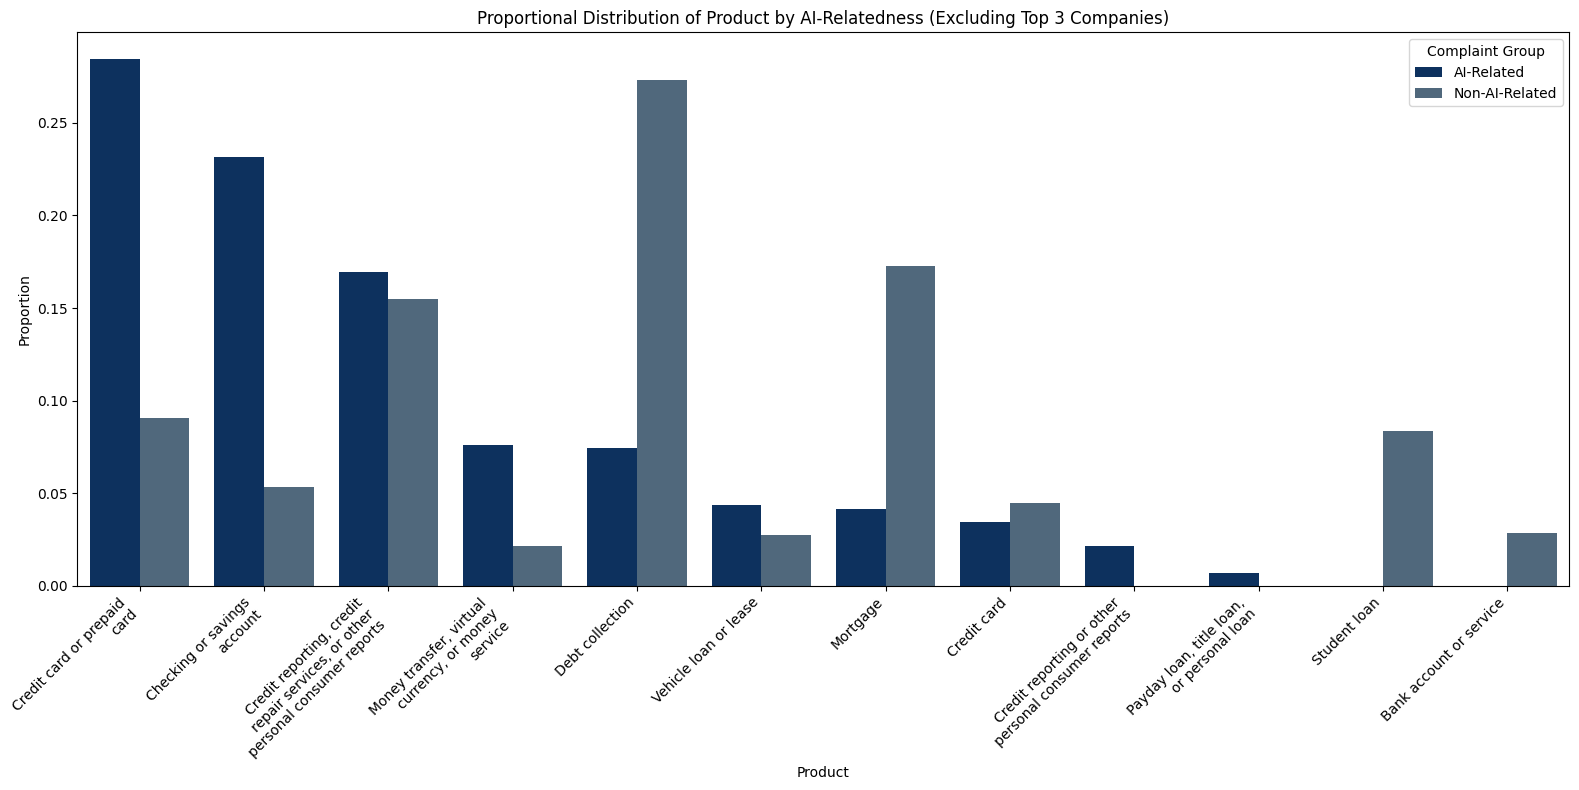

/tmp/ipython-input-2764702489.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels)


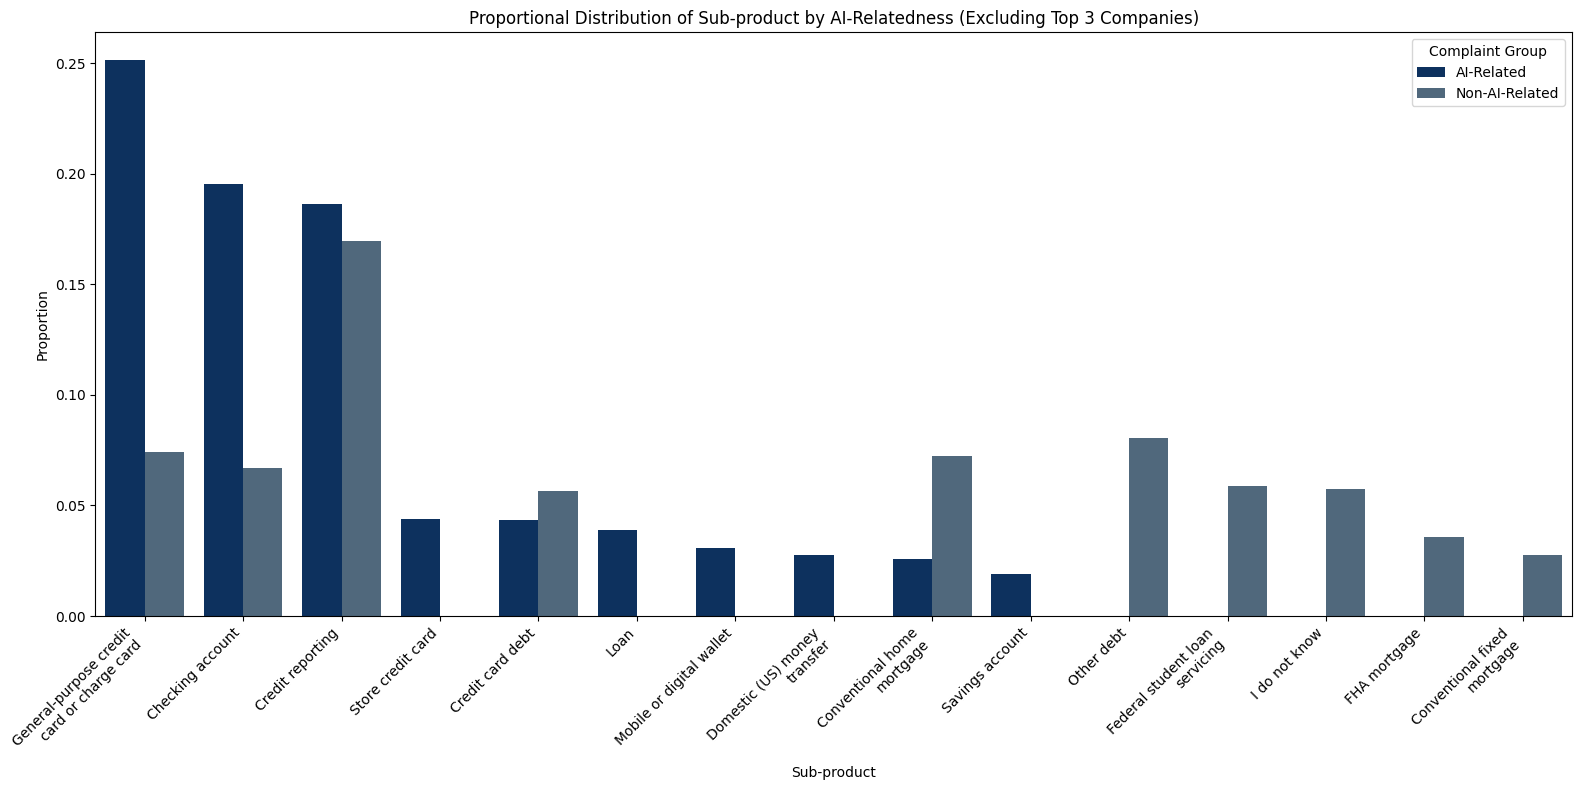

/tmp/ipython-input-2764702489.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels)


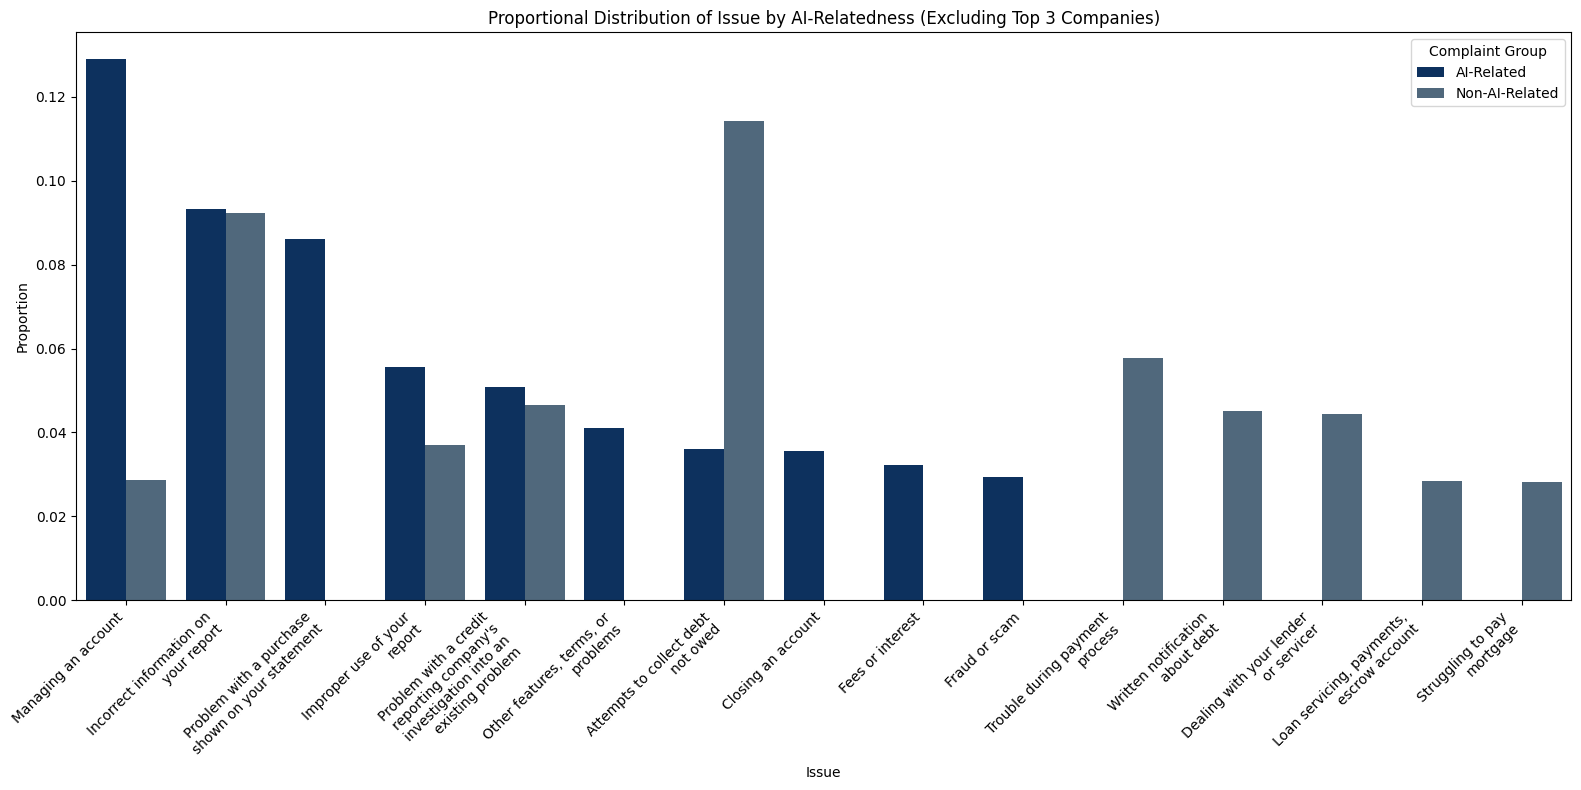

/tmp/ipython-input-2764702489.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels)


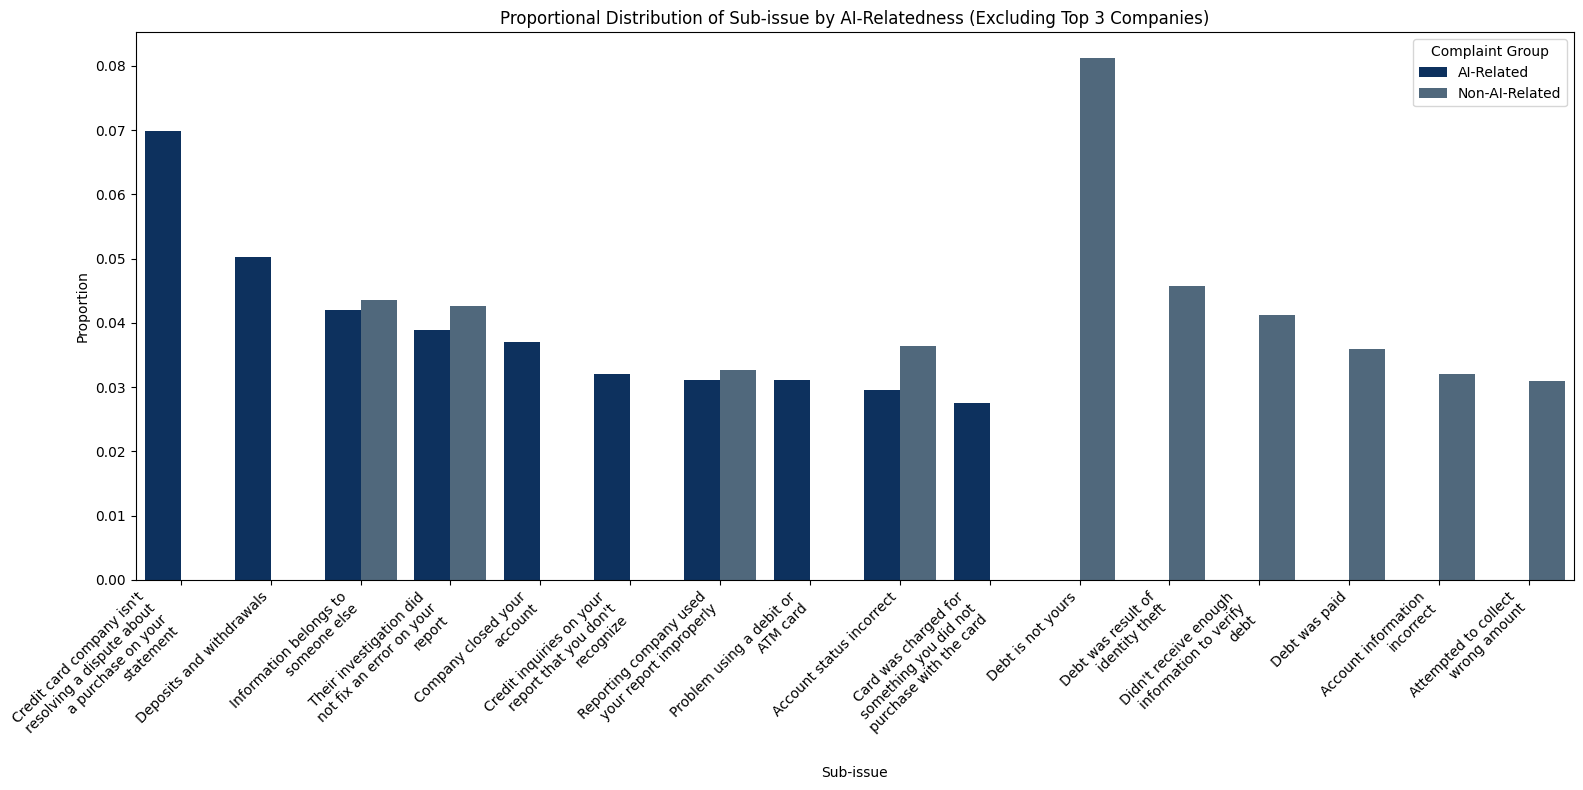

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from textwrap import fill

# Identify the top 3 companies to exclude
top_3_companies = company_complaint_counts.head(3).index.tolist()
print(f"Excluding top 3 companies: {top_3_companies}")

# Filter the main DataFrame to exclude complaints from these companies
df_filtered_companies = df[~df['Company'].isin(top_3_companies)].copy()

# Re-create df_ai_dummy_1 and df_ai_dummy_0 from the filtered DataFrame
df_ai_dummy_1_filtered = df_filtered_companies[df_filtered_companies['AI_dummy'] == '1'].copy()
df_ai_dummy_0_filtered = df_filtered_companies[df_filtered_companies['AI_dummy'] == '0'].copy()

comparison_columns = ['Product', 'Sub-product', 'Issue', 'Sub-issue']
custom_palette_products = ['#00306B', '#496983']

for col in comparison_columns:
    # Calculate proportional distributions for AI-Related complaints (filtered data)
    ai_related_dist_filtered = (
        df_ai_dummy_1_filtered[col]
        .value_counts(normalize=True)
        .head(10)
        .reset_index()
    )
    ai_related_dist_filtered.columns = [col, 'Proportion']
    ai_related_dist_filtered['Group'] = 'AI-Related'

    # Calculate proportional distributions for Non-AI-Related complaints
    non_ai_related_dist_filtered = (
        df_ai_dummy_0_filtered[col]
        .value_counts(normalize=True)
        .head(10)
        .reset_index()
    )
    non_ai_related_dist_filtered.columns = [col, 'Proportion']
    non_ai_related_dist_filtered['Group'] = 'Non-AI-Related'

    # Combine both
    combined_dist_filtered = pd.concat([
        ai_related_dist_filtered,
        non_ai_related_dist_filtered
    ])

    # Create plot
    plt.figure(figsize=(16, 8))
    ax = sns.barplot(
        x=col, y='Proportion',
        hue='Group',
        data=combined_dist_filtered,
        palette=custom_palette_products
    )

    # Title & labels
    plt.title(f'Proportional Distribution of {col} by AI-Relatedness (Excluding Top 3 Companies)')
    plt.xlabel(col)
    plt.ylabel('Proportion')

    # Rotate x labels
    plt.xticks(rotation=45, ha='right', fontsize=10)

    # Wrap long labels to max width (20 chars per line)
    wrapped_labels = [
        fill(label.get_text(), 25) for label in ax.get_xticklabels()
    ]
    ax.set_xticklabels(wrapped_labels)

    plt.legend(title='Complaint Group')
    plt.tight_layout()
    plt.show()


## Companies with the Most Complaints

In [ ]:
company_complaint_counts = df['Company'].value_counts()

print("Top 10 Companies with the Most Complaints:")
display(company_complaint_counts.head(10))

Top 10 Companies with the Most Complaints:


,count
Company,
"EQUIFAX, INC.",85344
"TRANSUNION INTERMEDIATE HOLDINGS, INC.",84864
Experian Information Solutions Inc.,81098
"BANK OF AMERICA, NATIONAL ASSOCIATION",11865
WELLS FARGO & COMPANY,11507
JPMORGAN CHASE & CO.,11428
CAPITAL ONE FINANCIAL CORPORATION,11041
"CITIBANK, N.A.",10533
SYNCHRONY FINANCIAL,6018


## Compare Complaint Type Distributions

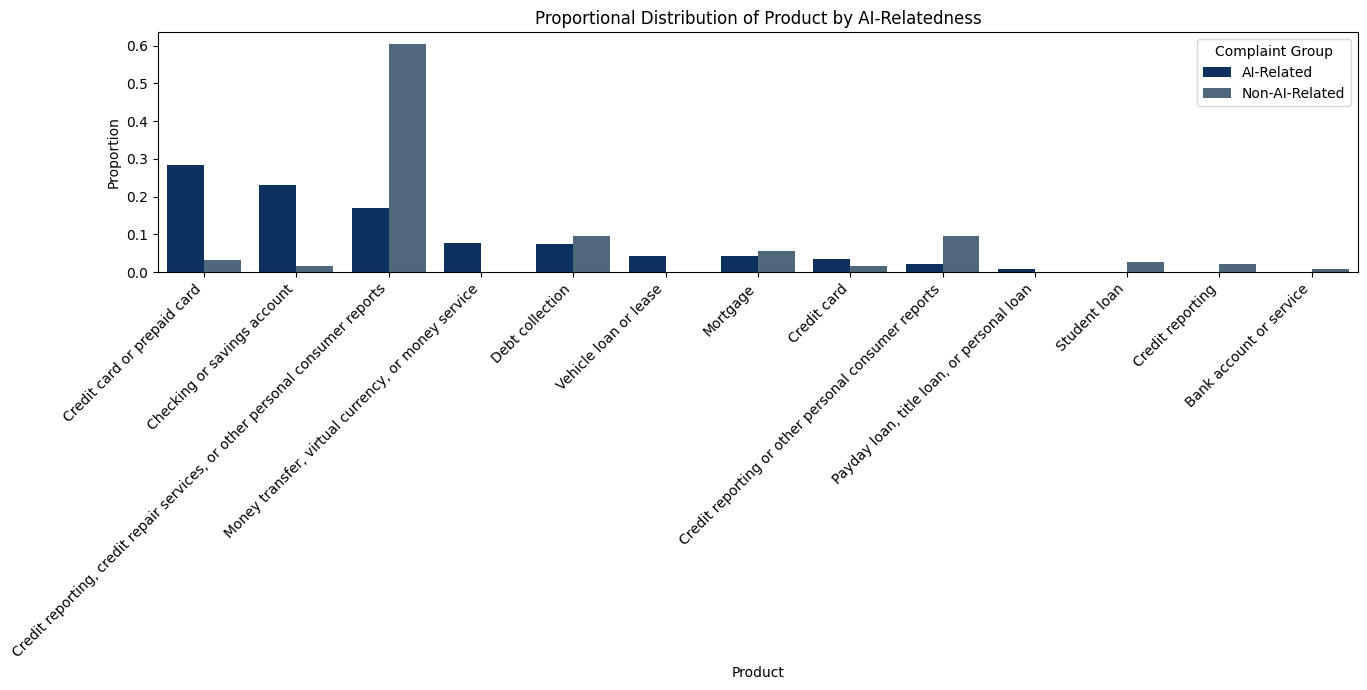

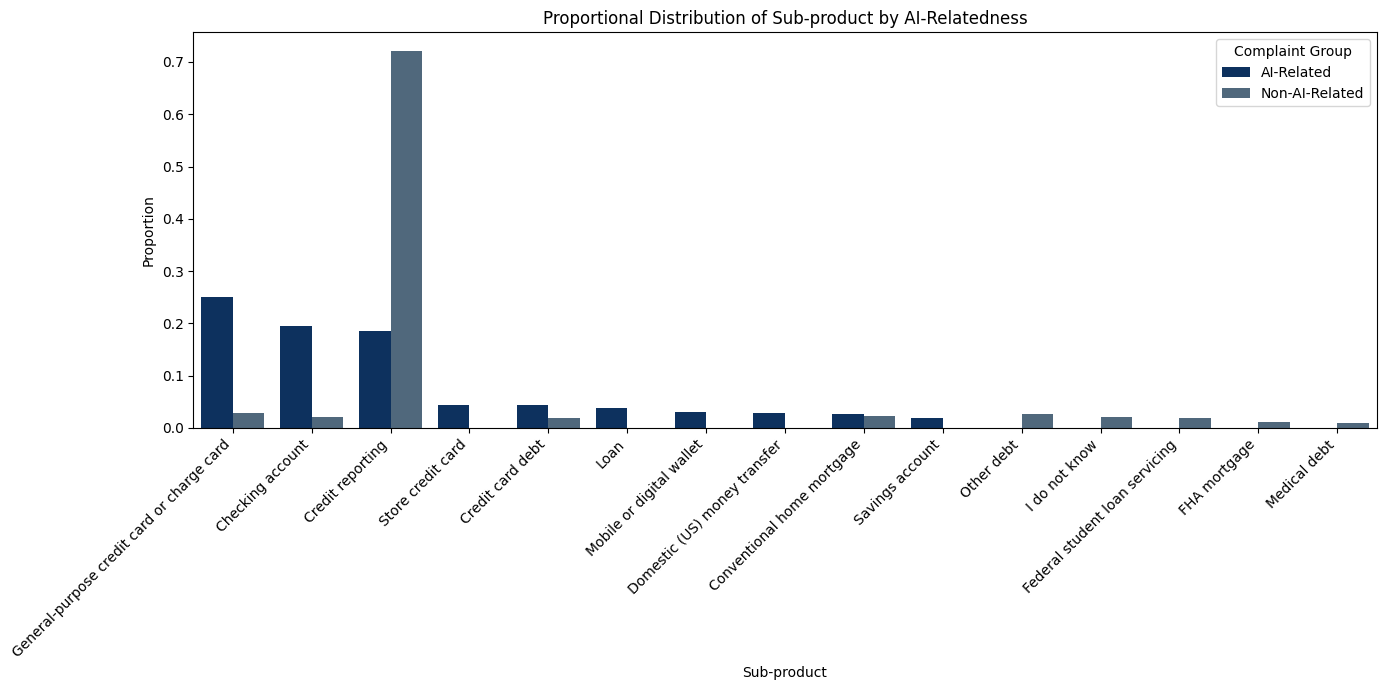

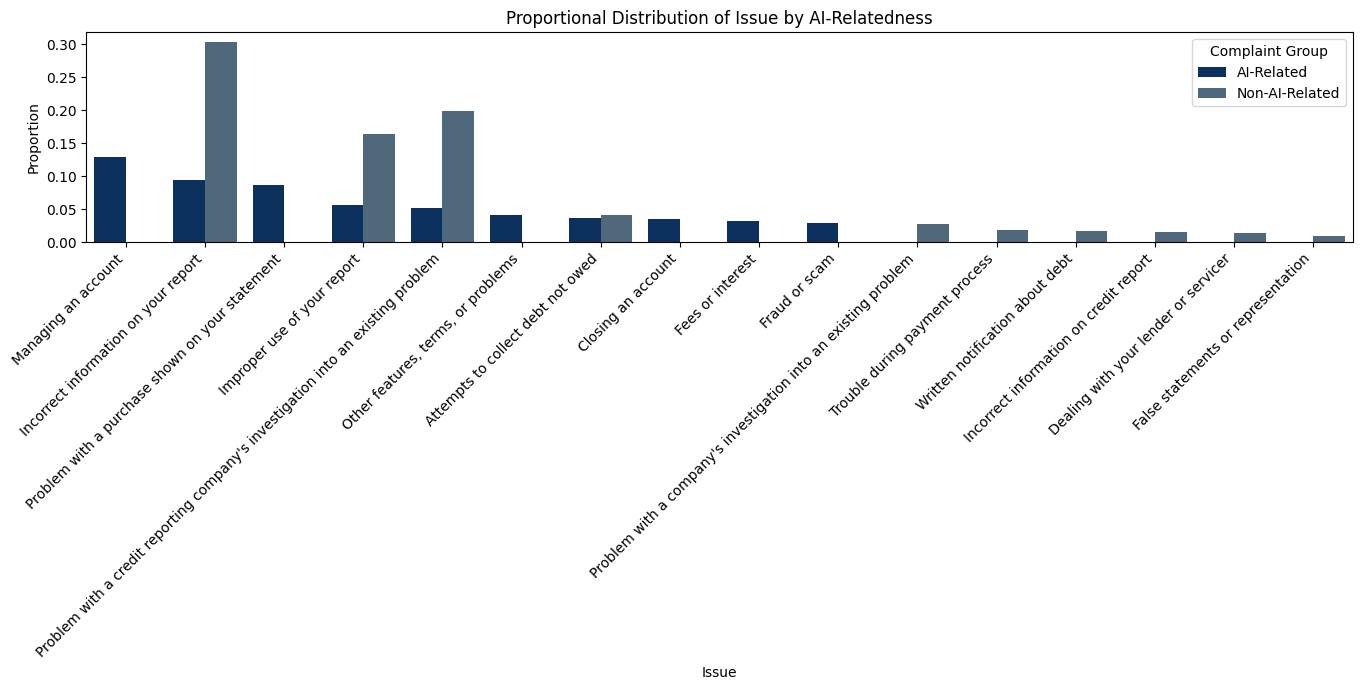

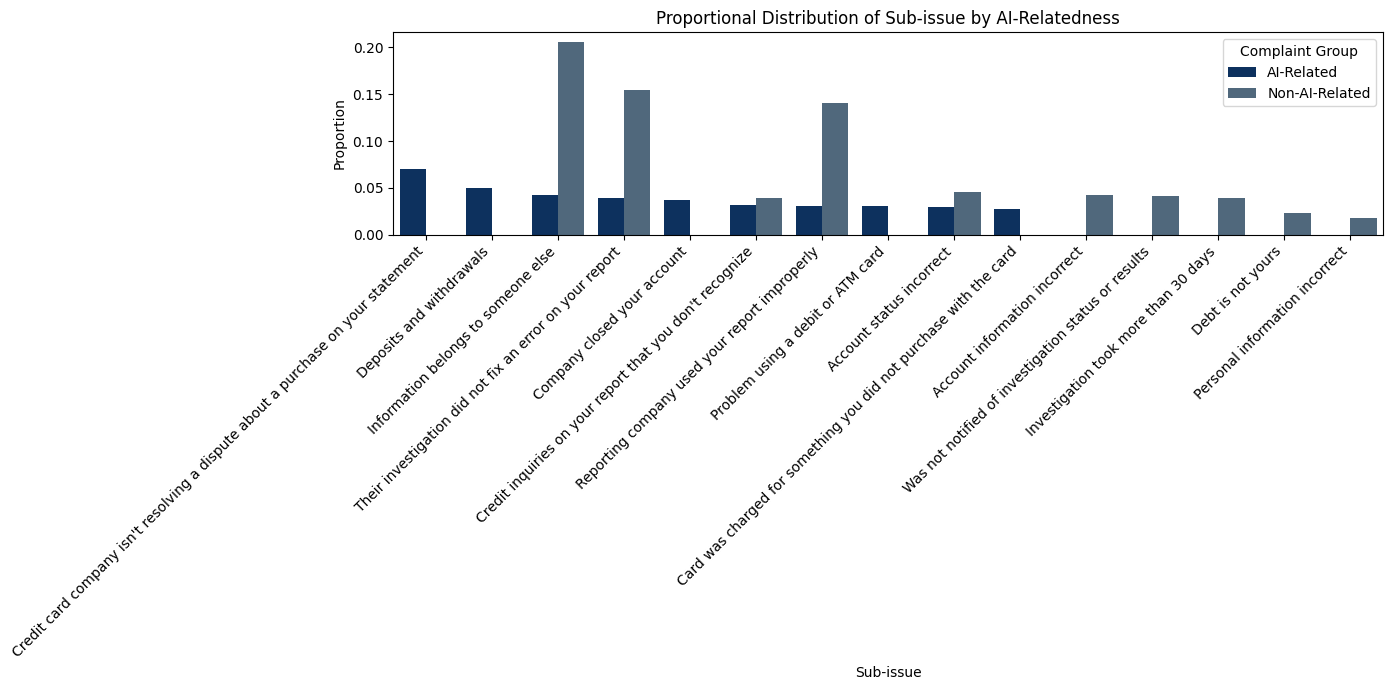

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Re-create df_ai_dummy_1 and df_ai_dummy_0 to ensure they are defined
df_ai_dummy_1 = df[df['AI_dummy'] == '1'].copy()
df_ai_dummy_0 = df[df['AI_dummy'] == '0'].copy()

comparison_columns = ['Product', 'Sub-product', 'Issue', 'Sub-issue']

# Define the custom color palette
custom_palette_products = ['#00306B', '#496983']

for col in comparison_columns:
    # Calculate proportional distributions for AI-Related complaints
    ai_related_dist = df_ai_dummy_1[col].value_counts(normalize=True).head(10).reset_index()
    ai_related_dist.columns = [col, 'Proportion']
    ai_related_dist['Group'] = 'AI-Related'

    # Calculate proportional distributions for Non-AI-Related complaints
    non_ai_related_dist = df_ai_dummy_0[col].value_counts(normalize=True).head(10).reset_index()
    non_ai_related_dist.columns = [col, 'Proportion']
    non_ai_related_dist['Group'] = 'Non-AI-Related'

    # Concatenate the two DataFrames
    combined_dist = pd.concat([ai_related_dist, non_ai_related_dist])

    # Create grouped bar chart with custom colors
    plt.figure(figsize=(14, 7))
    sns.barplot(x=col, y='Proportion', hue='Group', data=combined_dist, palette=custom_palette_products)
    plt.title(f'Proportional Distribution of {col} by AI-Relatedness')
    plt.xlabel(col)
    plt.ylabel('Proportion')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Complaint Group')
    plt.tight_layout()
    plt.show()

/tmp/ipython-input-4265043012.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels)


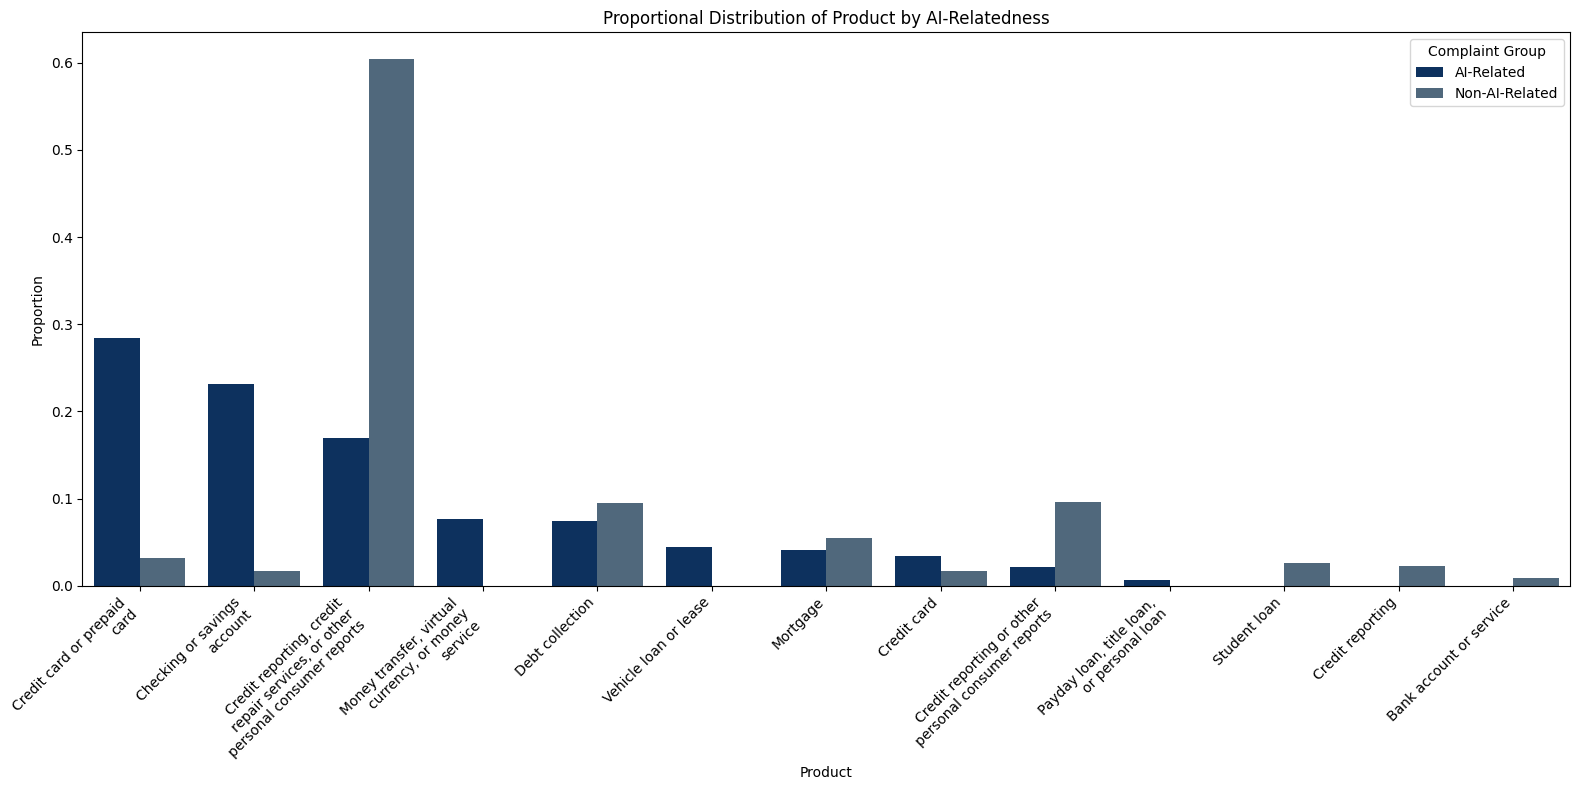

/tmp/ipython-input-4265043012.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels)


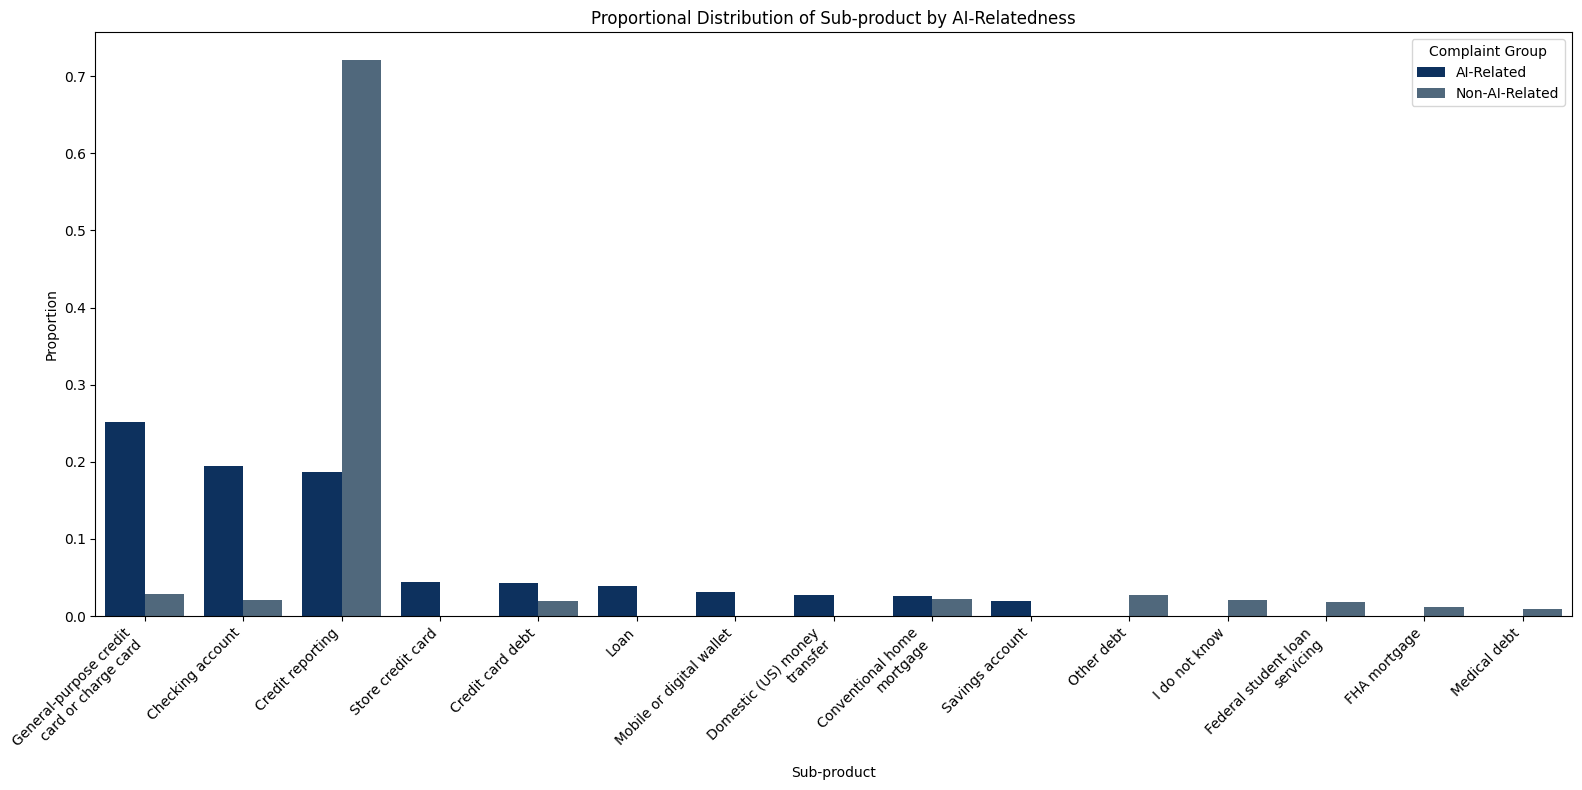

/tmp/ipython-input-4265043012.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels)


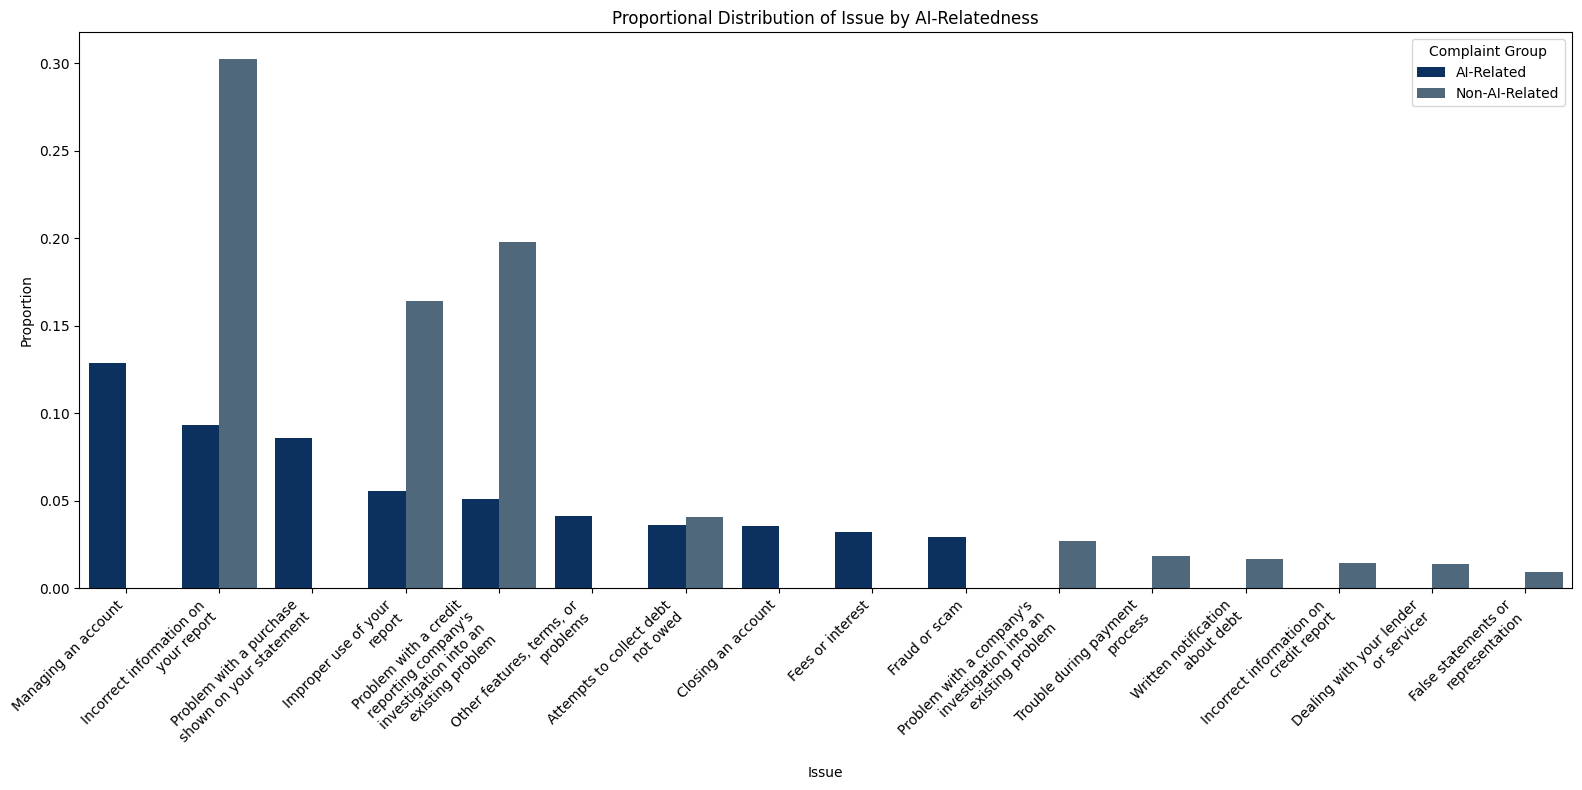

/tmp/ipython-input-4265043012.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels)


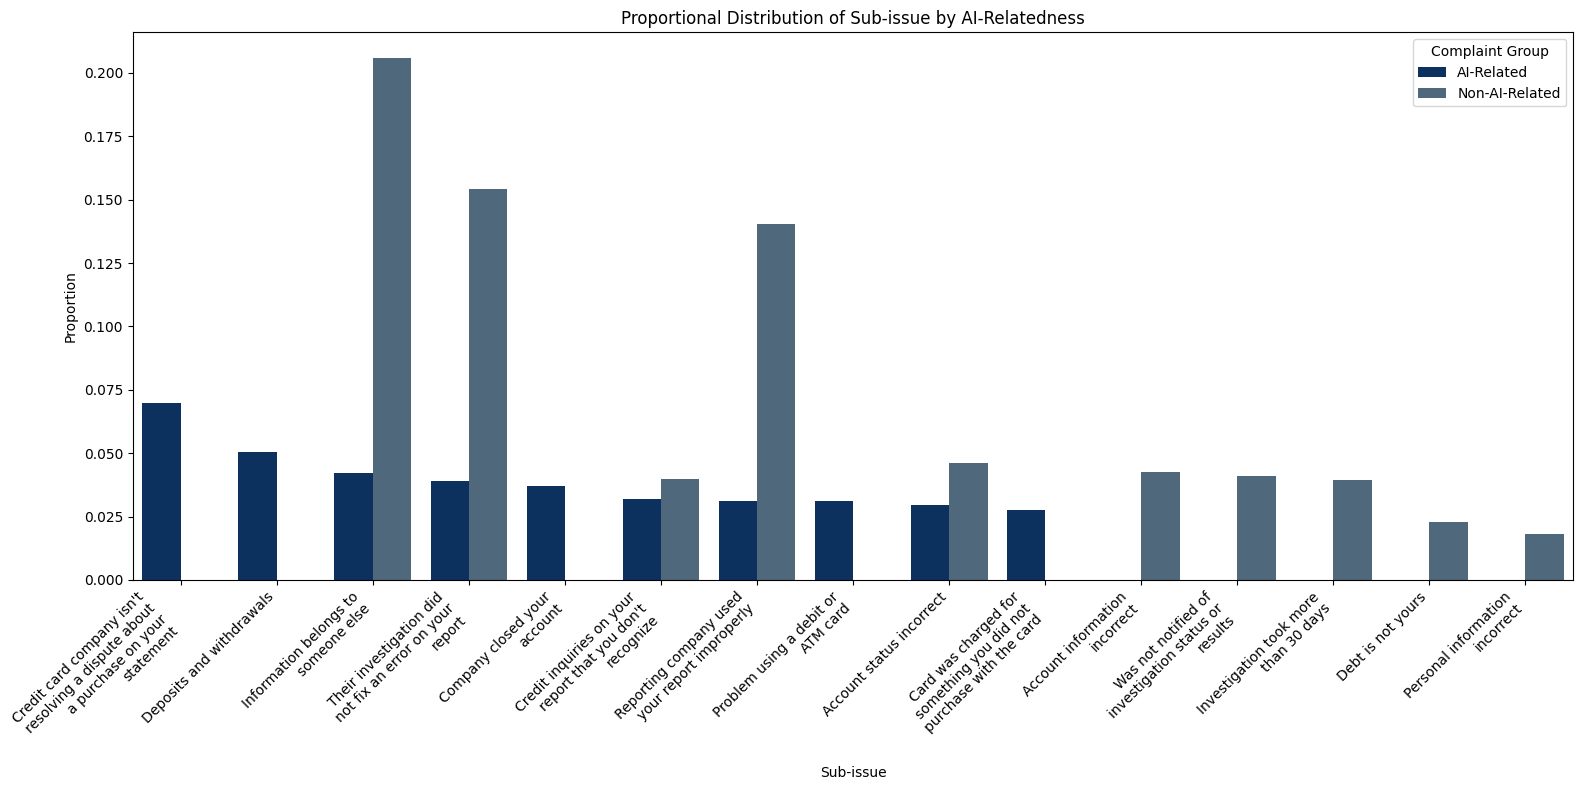

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from textwrap import fill

# Re-create df_ai_dummy_1 and df_ai_dummy_0 to ensure they are defined
df_ai_dummy_1 = df[df['AI_dummy'] == '1'].copy()
df_ai_dummy_0 = df[df['AI_dummy'] == '0'].copy()

comparison_columns = ['Product', 'Sub-product', 'Issue', 'Sub-issue']

# Define the custom color palette
custom_palette_products = ['#00306B', '#496983']

for col in comparison_columns:
    # Calculate proportional distributions for AI-Related complaints
    ai_related_dist = df_ai_dummy_1[col].value_counts(normalize=True).head(10).reset_index()
    ai_related_dist.columns = [col, 'Proportion']
    ai_related_dist['Group'] = 'AI-Related'

    # Calculate proportional distributions for Non-AI-Related complaints
    non_ai_related_dist = df_ai_dummy_0[col].value_counts(normalize=True).head(10).reset_index()
    non_ai_related_dist.columns = [col, 'Proportion']
    non_ai_related_dist['Group'] = 'Non-AI-Related'

    # Concatenate the two DataFrames
    combined_dist = pd.concat([ai_related_dist, non_ai_related_dist])

    # Create grouped bar chart with custom colors
    plt.figure(figsize=(16, 8))
    ax = sns.barplot(
        x=col, y='Proportion',
        hue='Group',
        data=combined_dist,
        palette=custom_palette_products
    )

    # Title and labels
    plt.title(f'Proportional Distribution of {col} by AI-Relatedness')
    plt.xlabel(col)
    plt.ylabel('Proportion')

    # Rotate labels
    plt.xticks(rotation=45, ha='right', fontsize=10)

    # Wrap x-axis labels to max width (20 chars per line)
    wrapped_labels = [
        fill(label.get_text(), 25) for label in ax.get_xticklabels()
    ]
    ax.set_xticklabels(wrapped_labels)

    plt.legend(title='Complaint Group')
    plt.tight_layout()
    plt.show()


## Product Problems for Paypal Holdings, Inc

In [ ]:
paypal_complaints = df[df['Company'] == 'Paypal Holdings, Inc']
paypal_products = paypal_complaints['Product'].unique()

print("Unique 'Product' categories for Paypal Holdings, Inc:")
for product in paypal_products:
    print(f"- {product}")

Unique 'Product' categories for Paypal Holdings, Inc:
- Debt collection
- Checking or savings account
- Money transfer, virtual currency, or money service
- Credit card or prepaid card
- Consumer Loan
- Payday loan, title loan, or personal loan
- Money transfers
- Bank account or service
- Credit card
- Credit reporting, credit repair services, or other personal consumer reports
- Prepaid card
- Credit reporting or other personal consumer reports
- Payday loan, title loan, personal loan, or advance loan


## Product Problems and AI-Relatedness for Paypal Holdings, Inc

In [ ]:
paypal_complaints = df[df['Company'] == 'Paypal Holdings, Inc'].copy()

print("--- Proportional Distribution of Products for Paypal Holdings, Inc ---")
display(paypal_complaints['Product'].value_counts(normalize=True))

print("\n--- AI_dummy Status for Paypal Holdings, Inc Complaints ---")
display(paypal_complaints['AI_dummy'].value_counts(normalize=True))

print("\n--- AI_introduction Dates for AI-Related Paypal Holdings, Inc Complaints ---")
paypal_ai_introduced = paypal_complaints[paypal_complaints['AI_dummy'] == '1'].copy()
if not paypal_ai_introduced.empty:
    display(paypal_ai_introduced['AI_introduction'].value_counts())
else:
    print("No AI-related complaints found for Paypal Holdings, Inc to show AI_introduction dates.")

--- Proportional Distribution of Products for Paypal Holdings, Inc ---


,proportion
Product,
"Money transfer, virtual currency, or money service",0.675703
Checking or savings account,0.080321
Debt collection,0.059906
Credit card or prepaid card,0.056225
Money transfers,0.037818
Bank account or service,0.034471
Credit card,0.029451
Prepaid card,0.008367
"Credit reporting, credit repair services, or other personal consumer reports",0.007028



--- AI_dummy Status for Paypal Holdings, Inc Complaints ---


,proportion
AI_dummy,
1,0.956493
0,0.043507



--- AI_introduction Dates for AI-Related Paypal Holdings, Inc Complaints ---


,count
AI_introduction,
2016-01-01 00:00:00,2858


## Analyze Average Sentiment, Tone, and Harm Scores


In [ ]:
print("\n--- Average Scores for AI-Related Complaints (AI_dummy=1) ---")
for col in ['emo_final', 'tone_final', 'harm_final']:
    # Ensure the column is numeric, coercing errors will turn non-numeric into NaN
    df_ai_dummy_1[col] = pd.to_numeric(df_ai_dummy_1[col], errors='coerce')
    average_score = df_ai_dummy_1[col].mean()
    print(f"Average {col}: {average_score:.2f}")

print("\n--- Average Scores for Non-AI-Related Complaints (AI_dummy=0) ---")
for col in ['emo_final', 'tone_final', 'harm_final']:
    # Ensure the column is numeric, coercing errors will turn non-numeric into NaN
    df_ai_dummy_0[col] = pd.to_numeric(df_ai_dummy_0[col], errors='coerce')
    average_score = df_ai_dummy_0[col].mean()
    print(f"Average {col}: {average_score:.2f}")


--- Average Scores for AI-Related Complaints (AI_dummy=1) ---
Average emo_final: 3.50
Average tone_final: 3.07
Average harm_final: 2.16

--- Average Scores for Non-AI-Related Complaints (AI_dummy=0) ---
Average emo_final: 3.30
Average tone_final: 2.93
Average harm_final: 1.97


/tmp/ipython-input-1943234660.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ai_dummy_1[col] = pd.to_numeric(df_ai_dummy_1[col], errors='coerce')
/tmp/ipython-input-1943234660.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ai_dummy_0[col] = pd.to_numeric(df_ai_dummy_0[col], errors='coerce')


Scores for AI complaints.

In [ ]:
print("\n--- AI-Related Complaints (AI_dummy=1) - Sentiment, Tone, Harm Analysis ---")

# emo_final analysis
print("\nValue counts for emo_final (AI_dummy=1):")
display(df_ai_dummy_1['emo_final'].value_counts())
print("\nProportional distribution for emo_final (AI_dummy=1):")
display(df_ai_dummy_1['emo_final'].value_counts(normalize=True))

# tone_final analysis
print("\nValue counts for tone_final (AI_dummy=1):")
display(df_ai_dummy_1['tone_final'].value_counts())
print("\nProportional distribution for tone_final (AI_dummy=1):")
display(df_ai_dummy_1['tone_final'].value_counts(normalize=True))

# harm_final analysis
print("\nValue counts for harm_final (AI_dummy=1):")
display(df_ai_dummy_1['harm_final'].value_counts())
print("\nProportional distribution for harm_final (AI_dummy=1):")
display(df_ai_dummy_1['harm_final'].value_counts(normalize=True))


--- AI-Related Complaints (AI_dummy=1) - Sentiment, Tone, Harm Analysis ---

Value counts for emo_final (AI_dummy=1):


,count
emo_final,
4,28334
3,26241
2,4629
5,4164
1,139



Proportional distribution for emo_final (AI_dummy=1):


,proportion
emo_final,
4,0.446156
3,0.413199
2,0.072890
5,0.065568
1,0.002189



Value counts for tone_final (AI_dummy=1):


...

,proportion
tone_final,
3,0.660935
4,0.205269
2,0.133103
1,0.000504
5,0.000189



Value counts for harm_final (AI_dummy=1):


,count
harm_final,
2,35938
3,18710
1,8859



Proportional distribution for harm_final (AI_dummy=1):


,proportion
harm_final,
2,0.565890
3,0.294613
1,0.139496


## Scores for non-AI complaints.


In [ ]:
print("\n--- Non-AI-Related Complaints (AI_dummy=0) - Sentiment, Tone, Harm Analysis ---")

# emo_final analysis
print("\nValue counts for emo_final (AI_dummy=0):")
display(df_ai_dummy_0['emo_final'].value_counts())
print("\nProportional distribution for emo_final (AI_dummy=0):")
display(df_ai_dummy_0['emo_final'].value_counts(normalize=True))

# tone_final analysis
print("\nValue counts for tone_final (AI_dummy=0):")
display(df_ai_dummy_0['tone_final'].value_counts())
print("\nProportional distribution for tone_final (AI_dummy=0):")
display(df_ai_dummy_0['tone_final'].value_counts(normalize=True))

# harm_final analysis
print("\nValue counts for harm_final (AI_dummy=0):")
display(df_ai_dummy_0['harm_final'].value_counts())
print("\nProportional distribution for harm_final (AI_dummy=0):")
display(df_ai_dummy_0['harm_final'].value_counts(normalize=True))


--- Non-AI-Related Complaints (AI_dummy=0) - Sentiment, Tone, Harm Analysis ---

Value counts for emo_final (AI_dummy=0):


,count
emo_final,
3,183272
4,129276
2,40070
5,12864
1,2151



Proportional distribution for emo_final (AI_dummy=0):


,proportion
emo_final,
3,0.498519
4,0.351644
2,0.108995
5,0.034991
1,0.005851



Value counts for tone_final (AI_dummy=0):


...

,proportion
tone_final,
3,0.593312
2,0.233809
4,0.170385
1,0.002293
5,0.000201



Value counts for harm_final (AI_dummy=0):


,count
harm_final,
2,232593
1,72734
3,62306



Proportional distribution for harm_final (AI_dummy=0):


,proportion
harm_final,
2,0.632677
1,0.197844
3,0.169479


## Compare Sentiment, Tone, and Harm Distributions

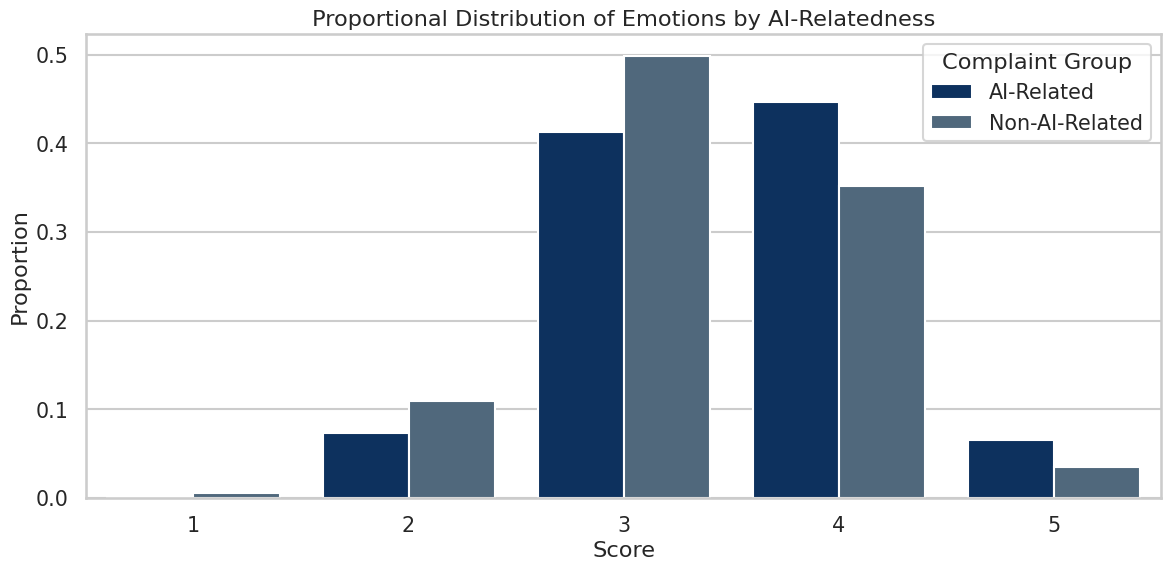

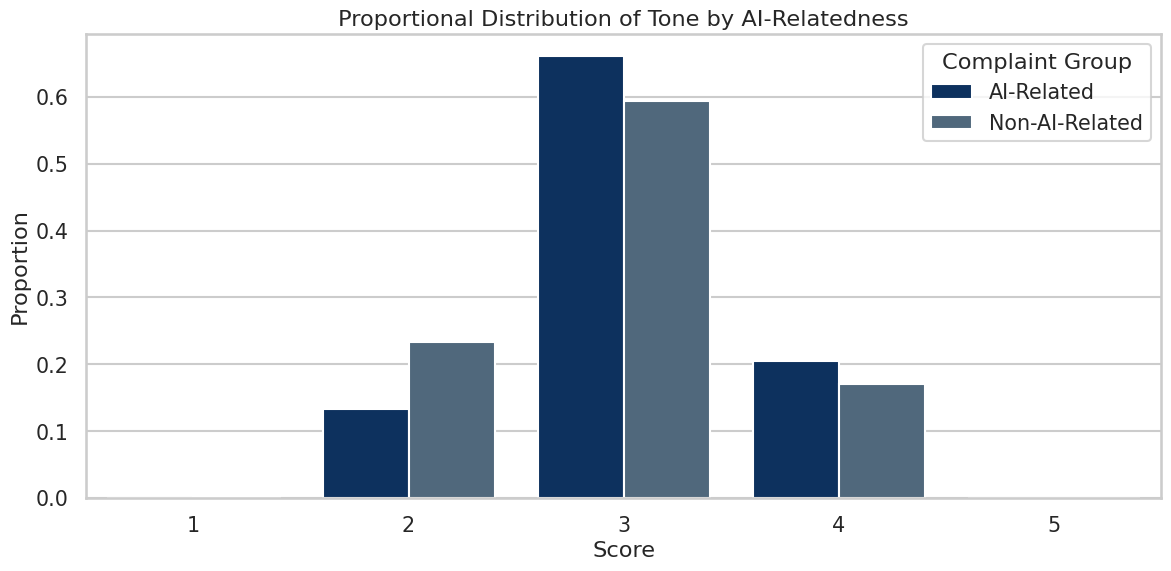

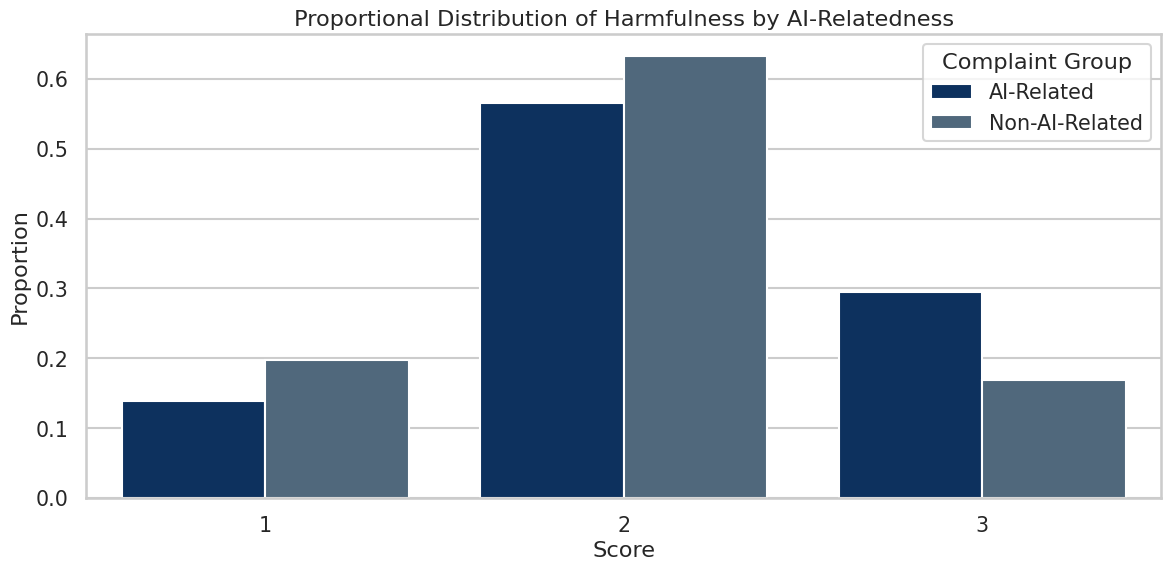

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Re-create df_ai_dummy_1 and df_ai_dummy_0 to ensure they are defined
df_ai_dummy_1 = df[df['AI_dummy'] == '1'].copy()
df_ai_dummy_0 = df[df['AI_dummy'] == '0'].copy()

comparison_columns = ['emo_final', 'tone_final', 'harm_final']

# Dictionary mapping your column names to prettier titles
pretty_titles = {
    'emo_final': 'Emotions',
    'tone_final': 'Tone',
    'harm_final': 'Harmfulness'
}

custom_palette = ['#00306B', '#496983']

for col in comparison_columns:
    ai_related_dist = df_ai_dummy_1[col].value_counts(normalize=True).reset_index()
    ai_related_dist.columns = [col, 'Proportion']
    ai_related_dist['Group'] = 'AI-Related'

    non_ai_related_dist = df_ai_dummy_0[col].value_counts(normalize=True).reset_index()
    non_ai_related_dist.columns = [col, 'Proportion']
    non_ai_related_dist['Group'] = 'Non-AI-Related'

    combined_dist = pd.concat([ai_related_dist, non_ai_related_dist])

    plt.figure(figsize=(12, 6))
    sns.barplot(x=col, y='Proportion', hue='Group', data=combined_dist, palette=custom_palette)

    plt.title(f'Proportional Distribution of {pretty_titles[col]} by AI-Relatedness')
    plt.xlabel('Score')
    plt.ylabel('Proportion')
    plt.xticks(rotation=0)
    plt.legend(title='Complaint Group')
    plt.tight_layout()
    plt.show()

## Perform Statistical Significance Tests


Conduct independent samples t-tests for `emo_final`, `tone_final`, and `harm_final` between the `df_ai_dummy_1` (AI-related) and `df_ai_dummy_0` (non-AI-related) DataFrames. We will use the `scipy.stats.ttest_ind` function for this purpose.



In [ ]:
from scipy import stats
import numpy as np

columns_to_test = ['emo_final', 'tone_final', 'harm_final']
alpha = 0.05 # Significance level

print("\n--- Independent Samples T-Tests (AI-Related vs. Non-AI-Related) ---")

for col in columns_to_test:
    # Ensure the column is numeric and drop NaNs for the test
    data_ai_related = pd.to_numeric(df_ai_dummy_1[col], errors='coerce').dropna()
    data_non_ai_related = pd.to_numeric(df_ai_dummy_0[col], errors='coerce').dropna()

    if len(data_ai_related) > 1 and len(data_non_ai_related) > 1:
        # Perform independent samples t-test (Welch's t-test for unequal variances)
        t_statistic, p_value = stats.ttest_ind(data_ai_related, data_non_ai_related, equal_var=False)

        mean_ai_related = data_ai_related.mean()
        mean_non_ai_related = data_non_ai_related.mean()

        print(f"\nColumn: {col}")
        print(f"Mean (AI-Related): {mean_ai_related:.2f}")
        print(f"Mean (Non-AI-Related): {mean_non_ai_related:.2f}")
        print(f"T-statistic: {t_statistic:.3f}")
        print(f"P-value: {p_value:.3f}")

        if p_value < alpha:
            print(f"Conclusion: The difference in means for '{col}' is statistically significant (p < {alpha}).")
        else:
            print(f"Conclusion: The difference in means for '{col}' is not statistically significant (p >= {alpha}).")
    else:
        print(f"\nNot enough data to perform t-test for column: {col} (AI-Related count: {len(data_ai_related)}, Non-AI-Related count: {len(data_non_ai_related)})")



--- Independent Samples T-Tests (AI-Related vs. Non-AI-Related) ---

Column: emo_final
Mean (AI-Related): 3.50
Mean (Non-AI-Related): 3.30
T-statistic: 63.101
P-value: 0.000
Conclusion: The difference in means for 'emo_final' is statistically significant (p < 0.05).

Column: tone_final
Mean (AI-Related): 3.07
Mean (Non-AI-Related): 2.93
T-statistic: 54.978
P-value: 0.000
Conclusion: The difference in means for 'tone_final' is statistically significant (p < 0.05).

Column: harm_final
Mean (AI-Related): 2.16
Mean (Non-AI-Related): 1.97
T-statistic: 67.205
P-value: 0.000
Conclusion: The difference in means for 'harm_final' is statistically significant (p < 0.05).


All these scores differences show an high significance level.

## Company-Level AI Complaint Distribution

In [ ]:
total_complaints_by_company = df['Company'].value_counts()
ai_related_complaints_by_company = df_ai_dummy_1['Company'].value_counts()

company_analysis = pd.DataFrame({
    'Total Complaints': total_complaints_by_company,
    'AI-Related Complaints': ai_related_complaints_by_company
}).fillna(0)

company_analysis['Proportion AI-Related'] = company_analysis['AI-Related Complaints'] / company_analysis['Total Complaints']

company_analysis_filtered = company_analysis[company_analysis['Total Complaints'] >= 100]

company_analysis_sorted = company_analysis_filtered.sort_values(by='Proportion AI-Related', ascending=False)

print("Top 10 Companies by Proportion of AI-Related Complaints (min 100 total complaints):")
display(company_analysis_sorted.head(10))

print("\nCompanies with 0 AI-related complaints (out of at least 100 total complaints):")
display(company_analysis_sorted[company_analysis_sorted['Proportion AI-Related'] == 0].head(10))

Top 10 Companies by Proportion of AI-Related Complaints (min 100 total complaints):


,Total Complaints,AI-Related Complaints,Proportion AI-Related
Company,,,
Chime Financial Inc,1451,1451.0,1.000000
"SANTANDER HOLDINGS USA, INC.",497,497.0,1.000000
ALLY FINANCIAL INC.,2033,2025.0,0.996065
TrueAccord Corp.,113,112.0,0.991150
"BMW Financial Services NA, LLC",271,263.0,0.970480
"Paypal Holdings, Inc",2988,2858.0,0.956493
UNITED SERVICES AUTOMOBILE ASSOCIATION,1408,1340.0,0.951705
Santander Consumer USA Holdings Inc.,1620,1516.0,0.935802
FISERV INC.,178,165.0,0.926966



Companies with 0 AI-related complaints (out of at least 100 total complaints):


,Total Complaints,AI-Related Complaints,Proportion AI-Related
Company,,,
"Aargon Agency, Inc.",251,0.0,0.0
"ACIMA CREDIT, LLC",255,0.0,0.0
AFNI INC.,588,0.0,0.0
"CLGF Holdco 1, LLC",432,0.0,0.0
CL Holdings LLC,913,0.0,0.0
"CITIZENS FINANCIAL GROUP, INC.",1158,0.0,0.0
"CCS Financial Services, Inc.",1123,0.0,0.0
CURO Intermediate Holdings,464,0.0,0.0
"Caliber Home Loans, Inc.",483,0.0,0.0


## Complaint Resolution Analysis (AI vs. Non-AI)

Compare metrics such as 'Company response to consumer', 'Timely response?', and 'Consumer disputed?' between AI-related and non-AI-related complaints.


In [ ]:
print("\n--- Analysis of 'Company response to consumer' ---")
print("Proportional distribution for 'Company response to consumer' (AI_dummy=1):")
display(df_ai_dummy_1['Company response to consumer'].value_counts(normalize=True))
print("\nProportional distribution for 'Company response to consumer' (AI_dummy=0):")
display(df_ai_dummy_0['Company response to consumer'].value_counts(normalize=True))

print("\n--- Analysis of 'Timely response?' ---")
print("Proportional distribution for 'Timely response?' (AI_dummy=1):")
display(df_ai_dummy_1['Timely response?'].value_counts(normalize=True))
print("\nProportional distribution for 'Timely response?' (AI_dummy=0):")
display(df_ai_dummy_0['Timely response?'].value_counts(normalize=True))

print("\n--- Analysis of 'Consumer disputed?' ---")
print("Proportional distribution for 'Consumer disputed?' (AI_dummy=1):")
display(df_ai_dummy_1['Consumer disputed?'].value_counts(normalize=True))
print("\nProportional distribution for 'Consumer disputed?' (AI_dummy=0):")
display(df_ai_dummy_0['Consumer disputed?'].value_counts(normalize=True))


--- Analysis of 'Company response to consumer' ---
Proportional distribution for 'Company response to consumer' (AI_dummy=1):


,proportion
Company response to consumer,
Closed with explanation,0.746800
Closed with monetary relief,0.137843
Closed with non-monetary relief,0.115342
Closed,0.000016



Proportional distribution for 'Company response to consumer' (AI_dummy=0):


,proportion
Company response to consumer,
Closed with explanation,0.700168
Closed with non-monetary relief,0.278433
Closed with monetary relief,0.020172
Closed,0.001134
Untimely response,0.000092



--- Analysis of 'Timely response?' ---
Proportional distribution for 'Timely response?' (AI_dummy=1):


...

,proportion
Timely response?,
Yes,0.994122
No,0.005878



--- Analysis of 'Consumer disputed?' ---
Proportional distribution for 'Consumer disputed?' (AI_dummy=1):


,proportion
Consumer disputed?,
No,0.775435
Yes,0.224565



Proportional distribution for 'Consumer disputed?' (AI_dummy=0):


,proportion
Consumer disputed?,
No,0.779727
Yes,0.220273


## Complaint Resolution Analysis (AI vs. Non-AI):

### Company Response to Consumer:
Non-AI-related complaints receive a much higher proportion of 'non-monetary relief' and a much lower proportion of 'monetary relief' compared to AI-related complaints.

### Timely Response?:
Both groups show a very high rate of timely responses, with only minor differences.

### Consumer Disputed?:
The proportion of consumers disputing the company's response is very similar between AI-related and non-AI-related complaints, indicating that AI involvement does not significantly alter the likelihood of a consumer disputing the outcome.

## Temporal Trends of AI Complaints



In [ ]:
df['Date received'] = pd.to_datetime(df['Date received'])
df['YearMonth'] = df['Date received'].dt.to_period('M')

# Create a new DataFrame for plotting, combining AI_dummy and YearMonth
trend_data = df.groupby(['YearMonth', 'AI_dummy']).size().unstack(fill_value=0)
trend_data.columns = ['Non-AI-Related', 'AI-Related', 'Unknown_AI_dummy'] # Rename columns for clarity

# Drop the 'Unknown_AI_dummy' column if it exists and is not relevant for comparison
if 'Unknown_AI_dummy' in trend_data.columns:
    trend_data = trend_data.drop(columns=['Unknown_AI_dummy'])

print("Trend data head:")
display(trend_data.head())


Trend data head:


,Non-AI-Related,AI-Related
YearMonth,,
2015-03,449,0
2015-04,1078,0
2015-05,1157,5
2015-06,1172,11
2015-07,1352,13


**Reasoning**:
Now that the trend data is prepared, I will plot the trend of AI-related and non-AI-related complaints over time using a line plot to visualize any increasing trends.



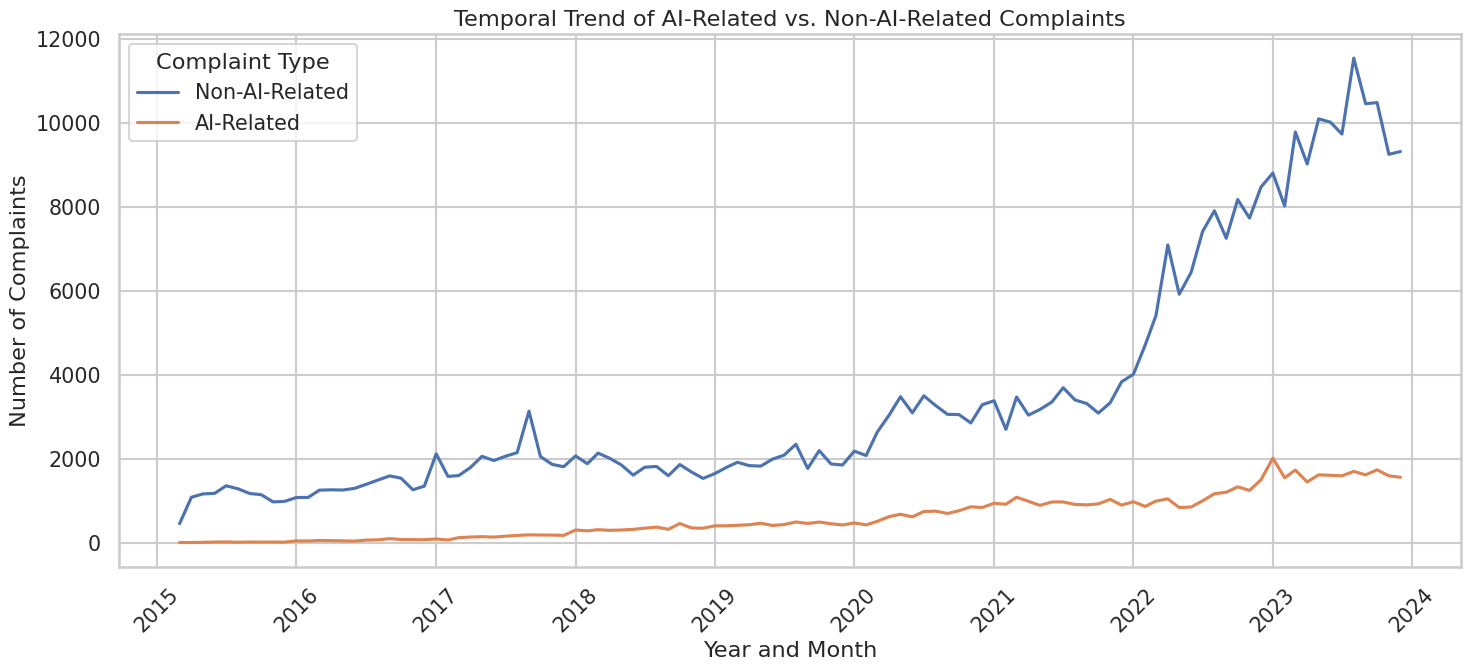

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reset index to make 'YearMonth' a column
trend_data_reset = trend_data.reset_index()

# Convert 'YearMonth' Period objects to datetime objects for plotting
trend_data_reset['YearMonth'] = trend_data_reset['YearMonth'].dt.to_timestamp()

# Melt the DataFrame to have 'Complaint_Type' and 'Count' columns for easy plotting with hue
trend_data_melted = trend_data_reset.melt(id_vars=['YearMonth'], var_name='Complaint_Type', value_name='Count')

plt.figure(figsize=(15, 7))
sns.lineplot(data=trend_data_melted, x='YearMonth', y='Count', hue='Complaint_Type')
plt.title('Temporal Trend of AI-Related vs. Non-AI-Related Complaints')
plt.xlabel('Year and Month')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.legend(title='Complaint Type')
plt.grid(True)
plt.tight_layout()
plt.show()

## AI Introduction Date vs. Complaint Characteristics

### Subtask:
Explore the `AI_introduction` column for complaints with specific dates, and analyze associated complaint characteristics.


**Reasoning**:
To analyze complaints with specific AI introduction dates, I will first filter the `df_ai_dummy_1` DataFrame to exclude 'Unknown' values in the `AI_introduction` column, and then convert the column to datetime objects for proper temporal analysis.



**Reasoning**:
To continue the analysis of the `AI_introduction` column, I will display the number of unique dates and their value counts to identify the most prominent AI introduction dates, as per the instructions.



## Temporal Trends of Sentiment, Tone, and Harm Scores

### Subtask:
Visualize the average `emo_final`, `tone_final`, and `harm_final` scores over the years for AI-related and non-AI-related complaints. To check no large changes have occured

In [ ]:
# Ensure 'Date received' is datetime and extract year
df['Date received'] = pd.to_datetime(df['Date received'])
df['Year'] = df['Date received'].dt.year

# Filter out 'Unknown' from AI_dummy for this analysis
df_filtered = df[df['AI_dummy'] != 'Unknown'].copy()

# Convert emo_final, tone_final, harm_final to numeric, coercing errors
for col in ['emo_final', 'tone_final', 'harm_final']:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

# Group by Year and AI_dummy, then calculate the mean for sentiment, tone, and harm
yearly_sentiment_trends = df_filtered.groupby(['Year', 'AI_dummy'])[['emo_final', 'tone_final', 'harm_final']].mean().reset_index()

# Melt the DataFrame for easier plotting
yearly_sentiment_melted = yearly_sentiment_trends.melt(id_vars=['Year', 'AI_dummy'],
                                                       var_name='Metric',
                                                       value_name='Average Score')

# Map AI_dummy values to more descriptive labels
yearly_sentiment_melted['AI_dummy'] = yearly_sentiment_melted['AI_dummy'].map({'0': 'Non-AI-Related', '1': 'AI-Related'})

print("Yearly Sentiment, Tone, and Harm Trends (Head):")
display(yearly_sentiment_melted.head())

Yearly Sentiment, Tone, and Harm Trends (Head):


,Year,AI_dummy,Metric,Average Score
0,2015,Non-AI-Related,emo_final,3.447486
1,2015,AI-Related,emo_final,3.538462
2,2016,Non-AI-Related,emo_final,3.433542
3,2016,AI-Related,emo_final,3.515885
4,2017,Non-AI-Related,emo_final,3.399345


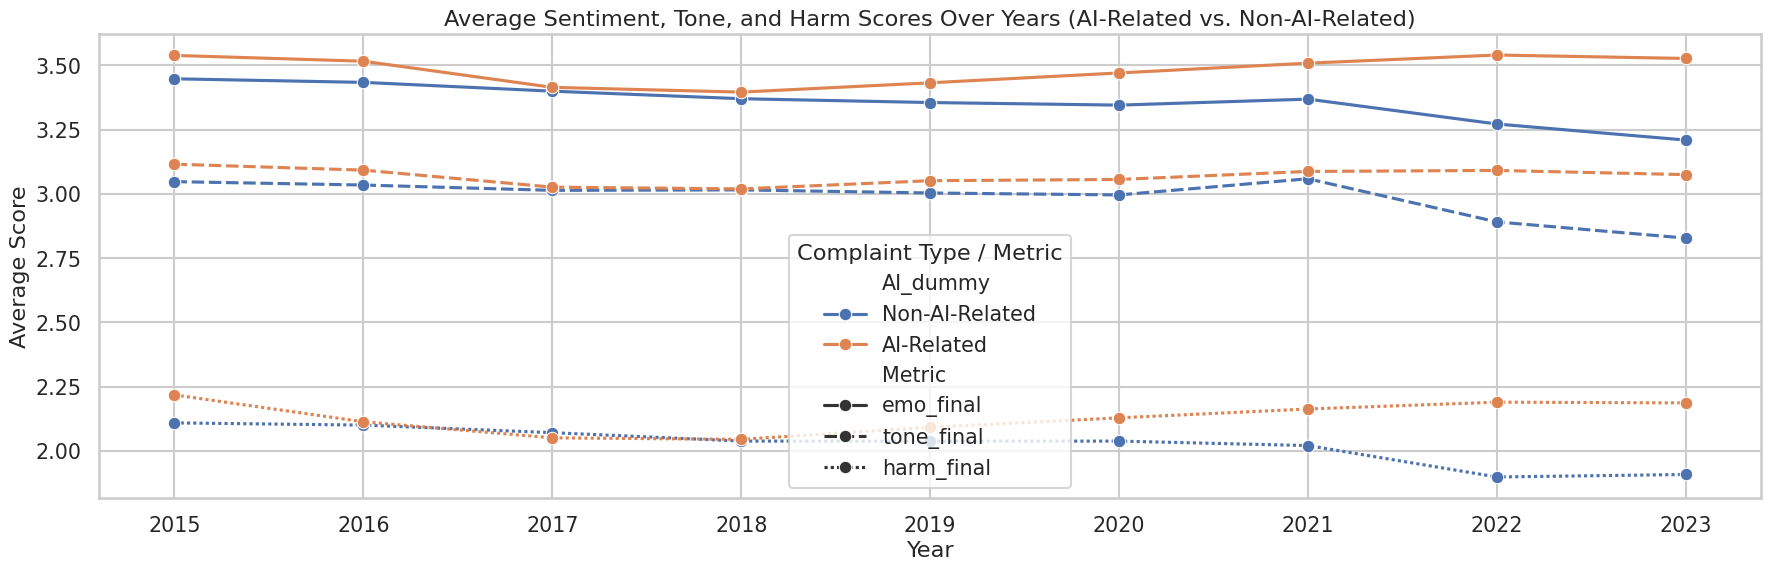

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 6))
sns.lineplot(data=yearly_sentiment_melted, x='Year', y='Average Score', hue='AI_dummy', style='Metric', marker='o')
plt.title('Average Sentiment, Tone, and Harm Scores Over Years (AI-Related vs. Non-AI-Related)')
plt.xlabel('Year')
plt.ylabel('Average Score')
plt.xticks(yearly_sentiment_melted['Year'].unique())
plt.legend(title='Complaint Type / Metric')
plt.grid(True)
plt.tight_layout()
plt.show()

Also check when using AI_overall

In [ ]:


# Ensure 'Date received' is datetime and extract year (if not already done)
df['Date received'] = pd.to_datetime(df['Date received'])
df['Year'] = df['Date received'].dt.year

# Filter out potential non-numeric values or NaNs in score columns
df_temp_filtered = df.copy()
for col in ['emo_final', 'tone_final', 'harm_final']:
    df_temp_filtered[col] = pd.to_numeric(df_temp_filtered[col], errors='coerce')

# Group by Year and AI_overall, then calculate the mean for sentiment, tone, and harm
yearly_sentiment_trends_overall = df_temp_filtered.groupby(['Year', 'AI_overall'])[['emo_final', 'tone_final', 'harm_final']].mean().reset_index()

# Melt the DataFrame for easier plotting
yearly_sentiment_melted_overall = yearly_sentiment_trends_overall.melt(id_vars=['Year', 'AI_overall'],
                                                                     var_name='Metric',
                                                                     value_name='Average Score')

# Map AI_overall values to more descriptive labels
yearly_sentiment_melted_overall['AI_overall'] = yearly_sentiment_melted_overall['AI_overall'].map({0: 'Non-AI-Related (AI_overall)', 1: 'AI-Related (AI_overall)'})

print("Yearly Sentiment, Tone, and Harm Trends (Head) using AI_overall:")
display(yearly_sentiment_melted_overall.head())

Yearly Sentiment, Tone, and Harm Trends (Head) using AI_overall:


,Year,AI_overall,Metric,Average Score
0,2015,Non-AI-Related (AI_overall),emo_final,3.392135
1,2015,AI-Related (AI_overall),emo_final,3.539204
2,2016,Non-AI-Related (AI_overall),emo_final,3.379139
3,2016,AI-Related (AI_overall),emo_final,3.521733
4,2017,Non-AI-Related (AI_overall),emo_final,3.362884


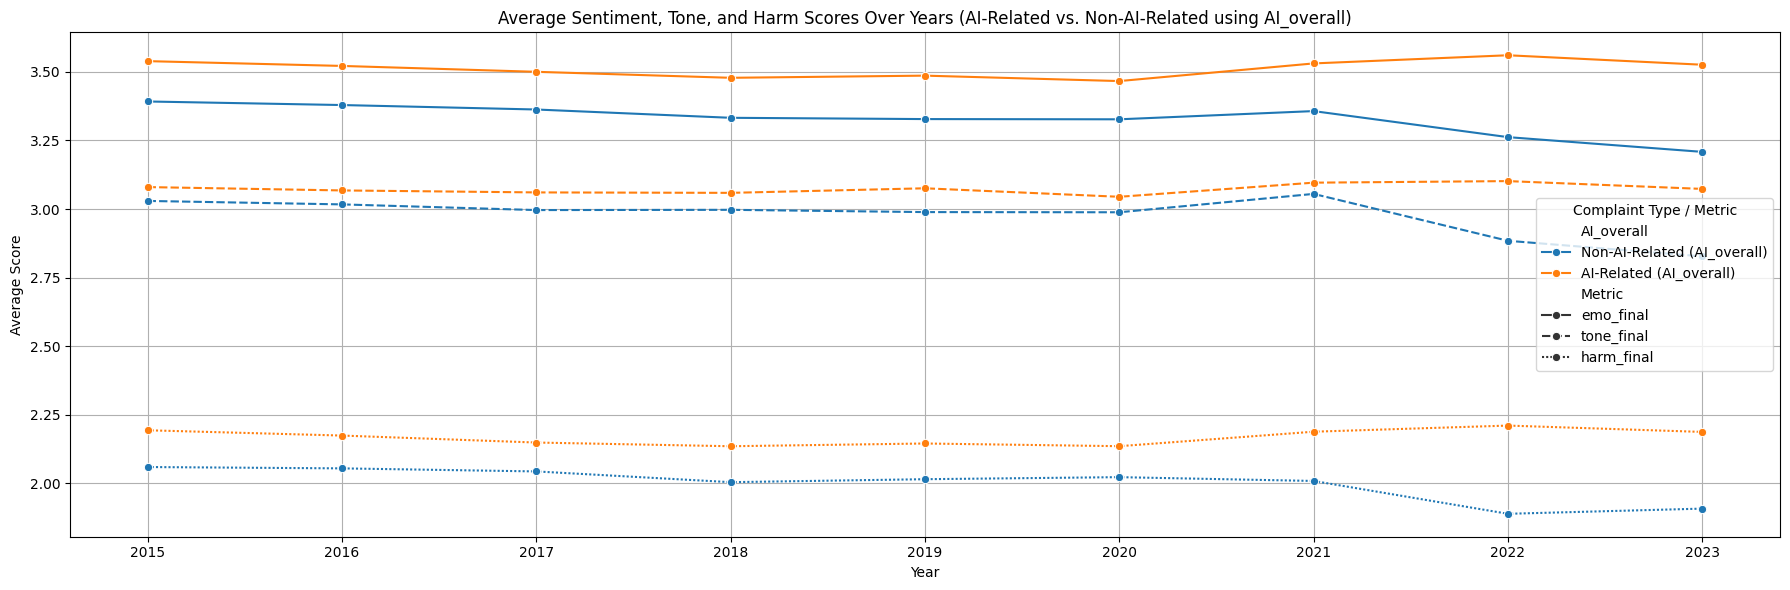

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 6))
sns.lineplot(data=yearly_sentiment_melted_overall, x='Year', y='Average Score', hue='AI_overall', style='Metric', marker='o')
plt.title('Average Sentiment, Tone, and Harm Scores Over Years (AI-Related vs. Non-AI-Related using AI_overall)')
plt.xlabel('Year')
plt.ylabel('Average Score')
plt.xticks(yearly_sentiment_melted_overall['Year'].unique())
plt.legend(title='Complaint Type / Metric')
plt.grid(True)
plt.tight_layout()
plt.show()

## Define Income Groups and Filter AI Complaints

### Subtask:
Define income groups based on `MEDIAN INCOME GENERAL` using quartiles and filter the `df` DataFrame to include only AI-related complaints (`AI_dummy` is '1') with valid `MEDIAN INCOME GENERAL` values. Then, display the first few rows of the filtered DataFrame and the count of complaints in each new income group.


In [ ]:
import numpy as np

# 1. Filter the original DataFrame `df` for AI-related complaints with valid MEDIAN INCOME GENERAL
df_ai_income = df[df['AI_dummy'] == '1'].copy()
df_ai_income = df_ai_income[df_ai_income['MEDIAN INCOME GENERAL'].notna()].copy()

# Ensure 'MEDIAN INCOME GENERAL' is numeric before qcut
df_ai_income['MEDIAN INCOME GENERAL'] = pd.to_numeric(df_ai_income['MEDIAN INCOME GENERAL'], errors='coerce')
df_ai_income = df_ai_income[df_ai_income['MEDIAN INCOME GENERAL'].notna()].copy()

# 2. Define four income group labels
income_labels = ['Low Income', 'Medium-Low Income', 'Medium-High Income', 'High Income']

# 3. Use pd.qcut to divide the MEDIAN INCOME GENERAL column into four quartiles
# Check if there are enough unique values for 4 quartiles
if len(df_ai_income['MEDIAN INCOME GENERAL'].unique()) >= 4:
    df_ai_income['Income_Group'] = pd.qcut(
        df_ai_income['MEDIAN INCOME GENERAL'],
        q=4,
        labels=income_labels,
        duplicates='drop' # Handle cases where there might be fewer than 4 unique quantiles
    )
else:
    print("Not enough unique values in 'MEDIAN INCOME GENERAL' to create 4 distinct income groups. Using fewer bins if duplicates='drop' leads to it.")
    df_ai_income['Income_Group'] = pd.qcut(
        df_ai_income['MEDIAN INCOME GENERAL'],
        q=4,
        labels=income_labels[:len(df_ai_income['MEDIAN INCOME GENERAL'].unique())],
        duplicates='drop'
    )

# 4. Display the first 5 rows of the df_ai_income DataFrame
print("First 5 rows of df_ai_income with new 'Income_Group' column:")
display(df_ai_income.head())

# 5. Display the count of complaints in each 'Income_Group'
print("\nCount of complaints in each 'Income_Group':")
display(df_ai_income['Income_Group'].value_counts())


First 5 rows of df_ai_income with new 'Income_Group' column:


,Unnamed: 0,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,...,tone_llm,harm_llm,emo_final,tone_final,harm_final,AI_introduction,AI_dummy,AI_overall,YearMonth,Income_Group
8,8,2022-11-02,Credit card or prepaid card,Store credit card,Getting a credit card,Card opened as result of identity theft or fraud,The account was opened with Micro Center and I...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,TN,...,NaN,NaN,3,3,2,2022-10-01 00:00:00,1,1,2022-11,Low Income
23,23,2023-01-14,Credit card or prepaid card,Government benefit card,Problem with a purchase or transfer,Card company isn't resolving a dispute about a...,"Hello, I was a victim of unauthorized transact...",Company has responded to the consumer and the ...,"BANK OF AMERICA, NATIONAL ASSOCIATION",CA,...,NaN,NaN,5,4,3,2018-06-01 00:00:00,1,1,2023-01,High Income
25,25,2019-12-05,Vehicle loan or lease,Lease,Problems at the end of the loan or lease,Termination fees or other problem when ending ...,"I had a 3-year (30,000 miles) vehicle lease fr...",NaN,"BMW Financial Services NA, LLC",VA,...,NaN,NaN,3,3,2,2015-10-01 00:00:00,1,1,2019-12,High Income
45,45,2019-07-17,Debt collection,Credit card debt,Attempts to collect debt not owed,Debt was paid,On XX/XX/XXXX I made my final payment to XXXX ...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",AZ,...,NaN,NaN,3,2,1,2018-01-01 00:00:00,1,1,2019-07,Low Income
58,58,2021-05-14,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account status incorrect,I just received an alert on my XXXX credit re...,NaN,TD BANK US HOLDING COMPANY,NJ,...,NaN,NaN,3,3,2,2019-01-01 00:00:00,1,1,2021-05,Medium-Low Income



Count of complaints in each 'Income_Group':


,count
Income_Group,
Medium-Low Income,15868
Low Income,15866
High Income,15863
Medium-High Income,15858


## Calculate Average Sentiment, Tone, and Harm per Income Group


In [ ]:
# 1. Ensure emo_final, tone_final, and harm_final columns are numeric and handle NaNs
for col in ['emo_final', 'tone_final', 'harm_final']:
    df_ai_income[col] = pd.to_numeric(df_ai_income[col], errors='coerce')

# Drop rows where any of these columns are NaN after conversion to ensure clean averages
df_ai_income_clean = df_ai_income.dropna(subset=['emo_final', 'tone_final', 'harm_final', 'Income_Group']).copy()

# 2. Group by 'Income_Group' and calculate the mean for the specified scores
average_scores_per_income_group = df_ai_income_clean.groupby('Income_Group')[['emo_final', 'tone_final', 'harm_final']].mean()

# 3. Display the resulting DataFrame
print("\nAverage Sentiment, Tone, and Harm Scores per Income Group (AI-Related Complaints):")
display(average_scores_per_income_group)



Average Sentiment, Tone, and Harm Scores per Income Group (AI-Related Complaints):


/tmp/ipython-input-517486167.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_scores_per_income_group = df_ai_income_clean.groupby('Income_Group')[['emo_final', 'tone_final', 'harm_final']].mean()


,emo_final,tone_final,harm_final
Income_Group,,,
Low Income,3.455313,3.051935,2.122841
Medium-Low Income,3.485884,3.068629,2.147404
Medium-High Income,3.515954,3.077753,2.166793
High Income,3.542331,3.087625,2.183257


In [ ]:
# 1. Ensure emo_final, tone_final, and harm_final columns are numeric and handle NaNs
for col in ['emo_final', 'tone_final', 'harm_final']:
    df_ai_income[col] = pd.to_numeric(df_ai_income[col], errors='coerce')

# Drop rows where any of these columns are NaN after conversion to ensure clean averages
df_ai_income_clean = df_ai_income.dropna(subset=['emo_final', 'tone_final', 'harm_final', 'Income_Group']).copy()

# 2. Group by 'Income_Group' and calculate the mean for the specified scores
average_scores_per_income_group = df_ai_income_clean.groupby('Income_Group', observed=False)[['emo_final', 'tone_final', 'harm_final']].mean()

# 3. Display the resulting DataFrame
print("\nAverage Sentiment, Tone, and Harm Scores per Income Group (AI-Related Complaints):")
display(average_scores_per_income_group)



Average Sentiment, Tone, and Harm Scores per Income Group (AI-Related Complaints):


,emo_final,tone_final,harm_final
Income_Group,,,
Low Income,3.455313,3.051935,2.122841
Medium-Low Income,3.485884,3.068629,2.147404
Medium-High Income,3.515954,3.077753,2.166793
High Income,3.542331,3.087625,2.183257


## Visualize Impact Across Income Groups


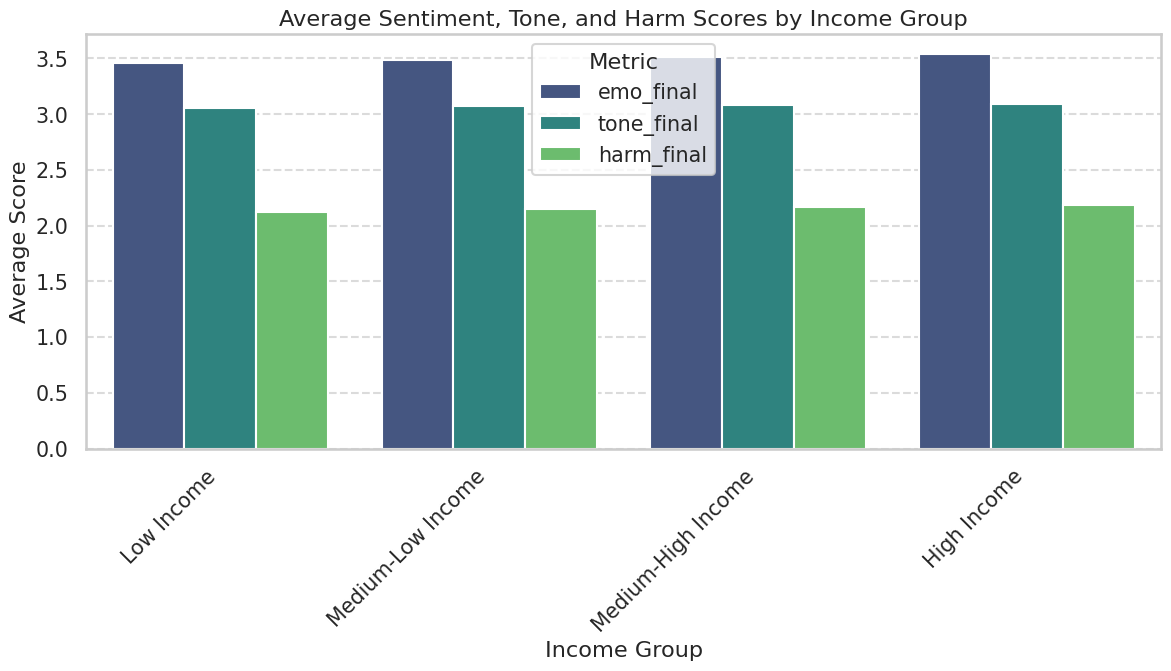

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index to make 'Income_Group' a column for melting
avg_scores_reset = average_scores_per_income_group.reset_index()

# Melt the DataFrame to long format
avg_scores_melted = avg_scores_reset.melt(id_vars=['Income_Group'],
                                          var_name='Metric',
                                          value_name='Average Score')

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Income_Group', y='Average Score', hue='Metric', data=avg_scores_melted, palette='viridis')

# Add title and labels
plt.title('Average Sentiment, Tone, and Harm Scores by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df['Date received'] = pd.to_datetime(df['Date received'])
df['Year'] = df['Date received'].dt.year

# Re-create df_ai_dummy_1 and df_ai_dummy_0 to include the new 'Year' column
df_ai_dummy_1 = df[df['AI_dummy'] == '1'].copy()
df_ai_dummy_0 = df[df['AI_dummy'] == '0'].copy()

print("Date received converted to datetime and Year extracted.")
print("First 5 rows of df_ai_dummy_1 with 'Year' column:")
display(df_ai_dummy_1.head())
print("First 5 rows of df_ai_dummy_0 with 'Year' column:")
display(df_ai_dummy_0.head())

Date received converted to datetime and Year extracted.
First 5 rows of df_ai_dummy_1 with 'Year' column:


,Unnamed: 0,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,...,emo_llm,tone_llm,harm_llm,emo_final,tone_final,harm_final,AI_introduction,AI_dummy,AI_overall,YearMonth
8,8,2022-11-02,Credit card or prepaid card,Store credit card,Getting a credit card,Card opened as result of identity theft or fraud,The account was opened with Micro Center and I...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,TN,...,NaN,NaN,NaN,3,3,2,2022-10-01 00:00:00,1,1,2022-11
23,23,2023-01-14,Credit card or prepaid card,Government benefit card,Problem with a purchase or transfer,Card company isn't resolving a dispute about a...,"Hello, I was a victim of unauthorized transact...",Company has responded to the consumer and the ...,"BANK OF AMERICA, NATIONAL ASSOCIATION",CA,...,NaN,NaN,NaN,5,4,3,2018-06-01 00:00:00,1,1,2023-01
25,25,2019-12-05,Vehicle loan or lease,Lease,Problems at the end of the loan or lease,Termination fees or other problem when ending ...,"I had a 3-year (30,000 miles) vehicle lease fr...",NaN,"BMW Financial Services NA, LLC",VA,...,NaN,NaN,NaN,3,3,2,2015-10-01 00:00:00,1,1,2019-12
45,45,2019-07-17,Debt collection,Credit card debt,Attempts to collect debt not owed,Debt was paid,On XX/XX/XXXX I made my final payment to XXXX ...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",AZ,...,NaN,NaN,NaN,3,2,1,2018-01-01 00:00:00,1,1,2019-07
58,58,2021-05-14,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account status incorrect,I just received an alert on my XXXX credit re...,NaN,TD BANK US HOLDING COMPANY,NJ,...,NaN,NaN,NaN,3,3,2,2019-01-01 00:00:00,1,1,2021-05


First 5 rows of df_ai_dummy_0 with 'Year' column:


,Unnamed: 0,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,...,emo_llm,tone_llm,harm_llm,emo_final,tone_final,harm_final,AI_introduction,AI_dummy,AI_overall,YearMonth
0,0,2022-03-17,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,In accordance with the Fair Credit Reporting A...,NaN,"EQUIFAX, INC.",FL,...,NaN,NaN,NaN,3,3,2,NaN,0,0,2022-03
1,1,2019-01-31,"Credit reporting, credit repair services, or o...",Credit reporting,Problem with a credit reporting company's inve...,Problem with personal statement of dispute,on XX/XX/XXXX I applied for a XXXX XXXX Reward...,NaN,"EQUIFAX, INC.",CA,...,NaN,NaN,NaN,3,3,2,NaN,0,0,2019-01
2,2,2023-07-18,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,the list of inquries listed below are a result...,NaN,"EQUIFAX, INC.",SC,...,NaN,NaN,NaN,3,3,2,NaN,0,0,2023-07
3,3,2023-01-05,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,This is my NUMEROUS request that I have been a...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,...,NaN,NaN,NaN,4,3,2,NaN,0,0,2023-01
4,4,2017-10-17,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,I have disputed this Account on many occasions...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NC,...,NaN,NaN,NaN,3,3,2,NaN,0,0,2017-10


In [ ]:
import pandas as pd

df['Date received'] = pd.to_datetime(df['Date received'])
df['Year'] = df['Date received'].dt.year

# Re-create df_ai_dummy_1 and df_ai_dummy_0 to include the new 'Year' column
df_ai_dummy_1 = df[df['AI_dummy'] == '1'].copy()
df_ai_dummy_0 = df[df['AI_dummy'] == '0'].copy()

print("Date received converted to datetime and Year extracted.")

# Define columns for which to calculate yearly proportional distributions
comparison_columns_temporal = ['Product', 'Sub-product', 'Issue', 'Sub-issue']

yearly_proportional_distributions = {}

for col in comparison_columns_temporal:
    yearly_proportional_distributions[col] = {
        'AI-Related': None,
        'Non-AI-Related': None
    }

    # Calculate yearly proportional distributions for AI-Related complaints
    ai_related_yearly_dist = df_ai_dummy_1.groupby('Year')[col].value_counts(normalize=True).mul(100).rename('proportion').reset_index()
    yearly_proportional_distributions[col]['AI-Related'] = ai_related_yearly_dist

    # Calculate yearly proportional distributions for Non-AI-Related complaints
    non_ai_related_yearly_dist = df_ai_dummy_0.groupby('Year')[col].value_counts(normalize=True).mul(100).rename('proportion').reset_index()
    yearly_proportional_distributions[col]['Non-AI-Related'] = non_ai_related_yearly_dist

# Display a sample of the calculated yearly proportional distributions for one of the columns
print("\nSample of yearly proportional distribution for 'Product' (AI-Related):")
display(yearly_proportional_distributions['Product']['AI-Related'].head())
print("\nSample of yearly proportional distribution for 'Product' (Non-AI-Related):")
display(yearly_proportional_distributions['Product']['Non-AI-Related'].head())


Date received converted to datetime and Year extracted.

Sample of yearly proportional distribution for 'Product' (AI-Related):


,Year,Product,proportion
0,2015,Consumer Loan,69.230769
1,2015,Bank account or service,16.666667
2,2015,Debt collection,8.974359
3,2015,Credit reporting,2.564103
4,2015,Money transfers,2.564103



Sample of yearly proportional distribution for 'Product' (Non-AI-Related):


,Year,Product,proportion
0,2015,Mortgage,25.139665
1,2015,Credit reporting,23.938547
2,2015,Debt collection,16.294227
3,2015,Credit card,14.711359
4,2015,Bank account or service,9.106145


In [ ]:
import pandas as pd


df['Date received'] = pd.to_datetime(df['Date received'])
df['Year'] = df['Date received'].dt.year

# Re-create df_ai_dummy_1 and df_ai_dummy_0 to include the new 'Year' column
df_ai_dummy_1 = df[df['AI_dummy'] == '1'].copy()
df_ai_dummy_0 = df[df['AI_dummy'] == '0'].copy()

print("Date received converted to datetime and Year extracted.")

# Define columns for which to calculate yearly proportional distributions
comparison_columns_temporal = ['Product', 'Sub-product', 'Issue', 'Sub-issue']

yearly_proportional_distributions = {}

for col in comparison_columns_temporal:
    yearly_proportional_distributions[col] = {
        'AI-Related': None,
        'Non-AI-Related': None
    }

    # Calculate yearly proportional distributions for AI-Related complaints
    ai_related_yearly_dist = df_ai_dummy_1.groupby('Year')[col].value_counts(normalize=True).mul(100).rename('proportion').reset_index()
    yearly_proportional_distributions[col]['AI-Related'] = ai_related_yearly_dist

    # Calculate yearly proportional distributions for Non-AI-Related complaints
    non_ai_related_yearly_dist = df_ai_dummy_0.groupby('Year')[col].value_counts(normalize=True).mul(100).rename('proportion').reset_index()
    yearly_proportional_distributions[col]['Non-AI-Related'] = non_ai_related_yearly_dist

# Display a sample of the calculated yearly proportional distributions for one of the columns
print("\nSample of yearly proportional distribution for 'Product' (AI-Related):")
display(yearly_proportional_distributions['Product']['AI-Related'].head())
print("\nSample of yearly proportional distribution for 'Product' (Non-AI-Related):")
display(yearly_proportional_distributions['Product']['Non-AI-Related'].head())

Date received converted to datetime and Year extracted.

Sample of yearly proportional distribution for 'Product' (AI-Related):


,Year,Product,proportion
0,2015,Consumer Loan,69.230769
1,2015,Bank account or service,16.666667
2,2015,Debt collection,8.974359
3,2015,Credit reporting,2.564103
4,2015,Money transfers,2.564103



Sample of yearly proportional distribution for 'Product' (Non-AI-Related):


,Year,Product,proportion
0,2015,Mortgage,25.139665
1,2015,Credit reporting,23.938547
2,2015,Debt collection,16.294227
3,2015,Credit card,14.711359
4,2015,Bank account or service,9.106145


## Visualize Temporal Trends of Top Complaint Types


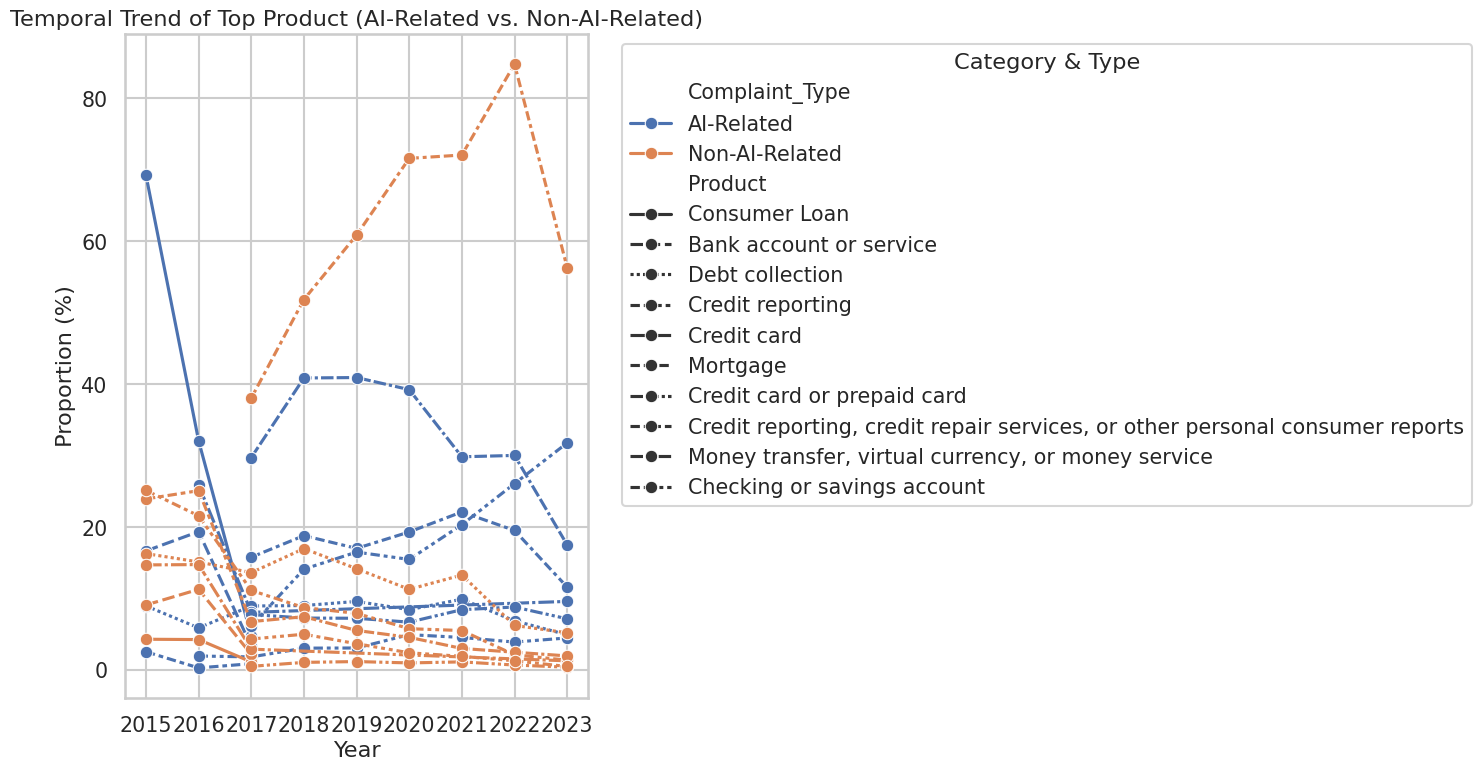

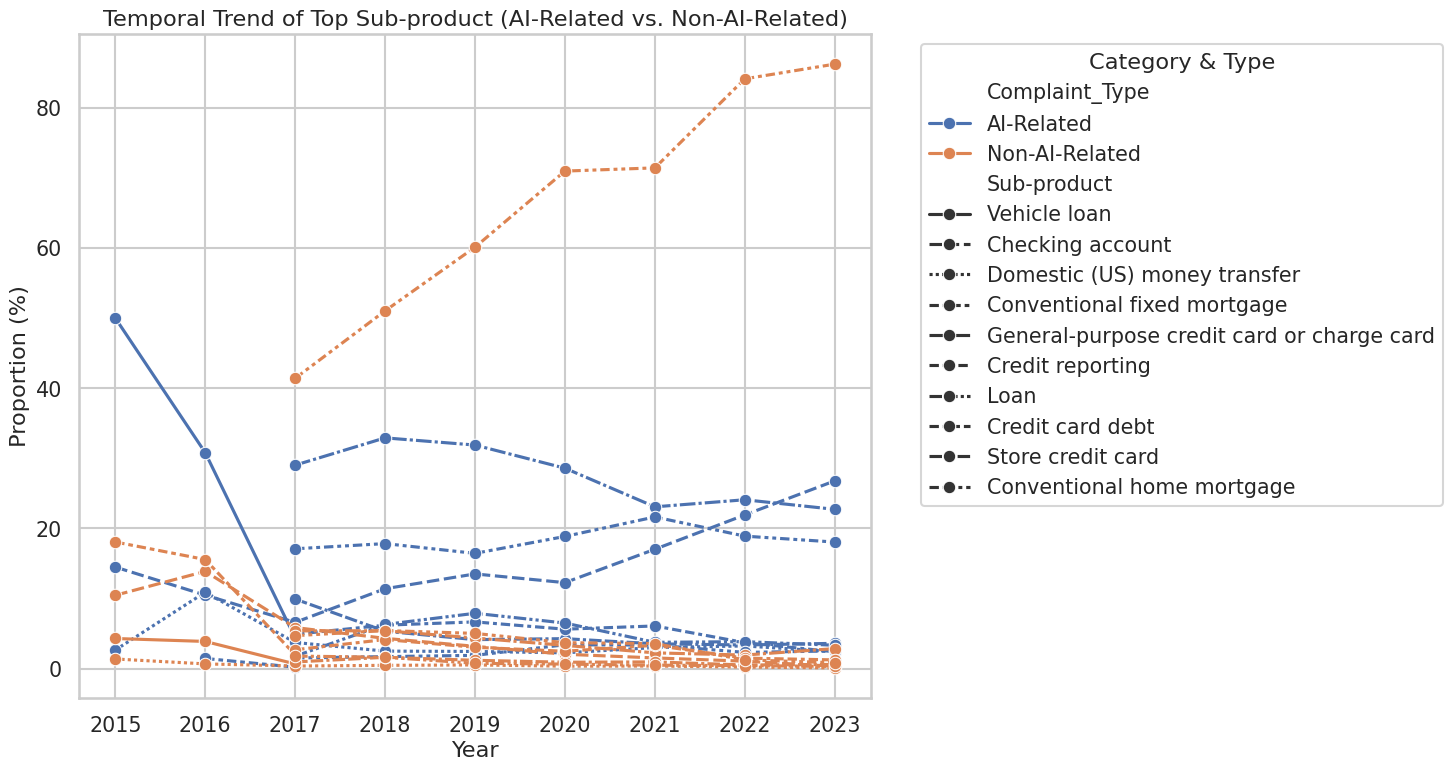

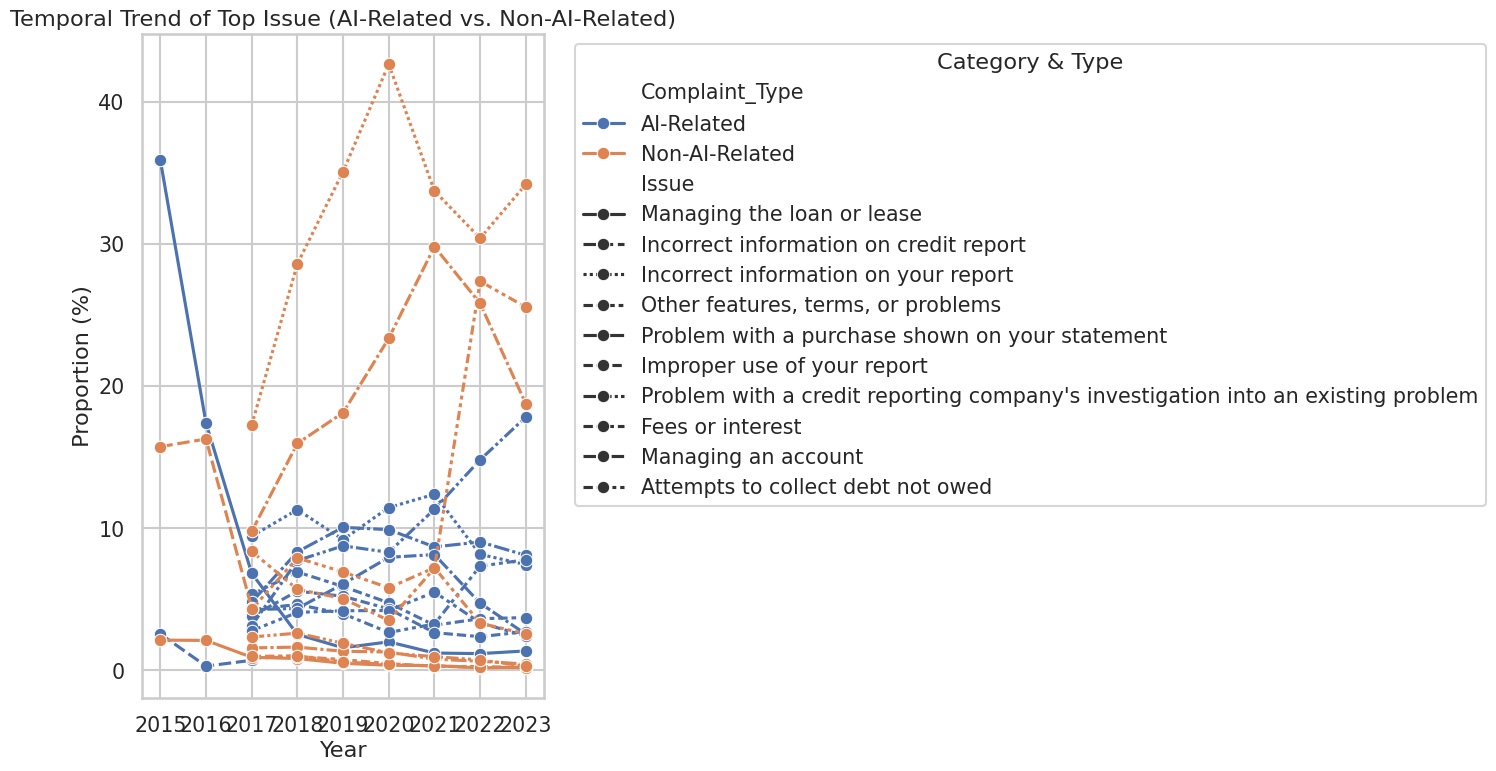

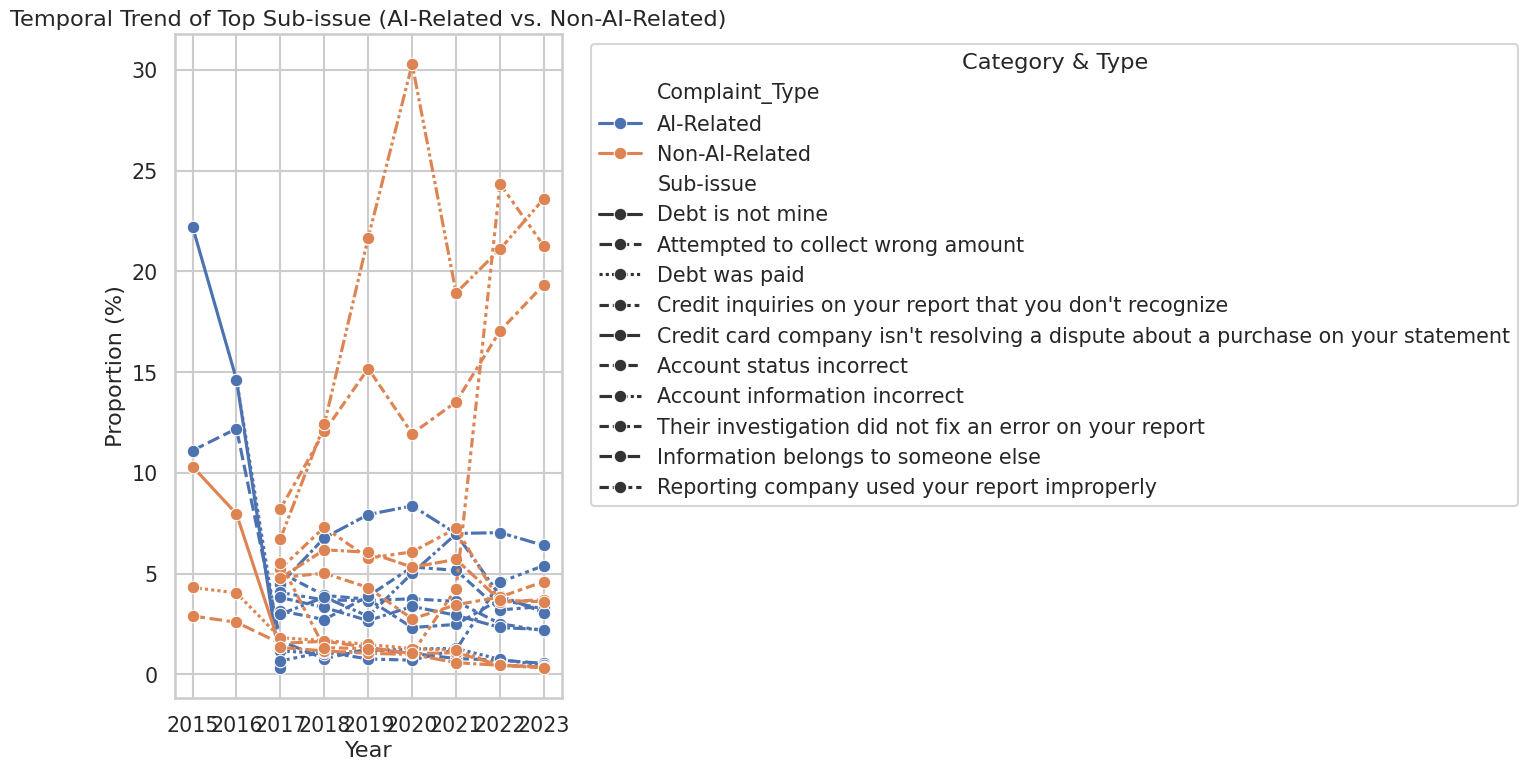

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set a consistent figure size for all plots
plt.rcParams['figure.figsize'] = (15, 8)

for col, distributions in yearly_proportional_distributions.items():
    # Add 'Complaint_Type' column to distinguish AI-related and Non-AI-related
    ai_df = distributions['AI-Related'].copy()
    ai_df['Complaint_Type'] = 'AI-Related'

    non_ai_df = distributions['Non-AI-Related'].copy()
    non_ai_df['Complaint_Type'] = 'Non-AI-Related'

    # Concatenate the two DataFrames
    combined_df = pd.concat([ai_df, non_ai_df])

    # Identify the top N categories based on overall proportion across all years
    # We'll calculate the sum of proportions for each category over all years
    # and then pick the top 10 unique categories.
    top_n = 10 # Number of top categories to visualize
    overall_category_proportions = combined_df.groupby(col)['proportion'].sum().nlargest(top_n).index

    # Filter the combined DataFrame to include only these top categories
    filtered_combined_df = combined_df[combined_df[col].isin(overall_category_proportions)]

    # Create line plot
    plt.figure()
    sns.lineplot(data=filtered_combined_df,
                 x='Year',
                 y='proportion',
                 hue='Complaint_Type',
                 style=col, # Use the category itself for different line styles
                 marker='o')

    plt.title(f'Temporal Trend of Top {col} (AI-Related vs. Non-AI-Related)')
    plt.xlabel('Year')
    plt.ylabel('Proportion (%)')
    plt.xticks(sorted(filtered_combined_df['Year'].unique())) # Ensure all years are shown
    plt.legend(title='Category & Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Summarize Temporal Changes in Complaint Types


In [ ]:
import pandas as pd

comparison_columns_temporal = ['Product', 'Sub-product', 'Issue', 'Sub-issue']

for col in comparison_columns_temporal:
    print(f"\n--- Yearly Proportional Distribution of Top {col} (AI-Related vs. Non-AI-Related) ---")

    ai_df = yearly_proportional_distributions[col]['AI-Related'].copy()
    non_ai_df = yearly_proportional_distributions[col]['Non-AI-Related'].copy()

    # Get all unique years
    all_years = sorted(pd.concat([ai_df['Year'], non_ai_df['Year']]).unique())

    # Create an empty list to store yearly summary DataFrames
    yearly_summaries = []

    for year in all_years:
        # Filter for the current year
        ai_year_data = ai_df[ai_df['Year'] == year].set_index(col)
        non_ai_year_data = non_ai_df[non_ai_df['Year'] == year].set_index(col)

        # Combine data for the current year
        combined_year_data = pd.concat([
            ai_year_data['proportion'].rename('AI-Related Proportion'),
            non_ai_year_data['proportion'].rename('Non-AI-Related Proportion')
        ], axis=1).fillna(0)

        # Sort by AI-Related proportion for better visibility of top AI categories
        combined_year_data = combined_year_data.sort_values(by='AI-Related Proportion', ascending=False).head(5)

        # Add 'Year' as a column and reset index for display
        combined_year_data = combined_year_data.reset_index()
        combined_year_data['Year'] = year
        yearly_summaries.append(combined_year_data)

    # Concatenate all yearly summaries for display
    if yearly_summaries:
        final_summary_table = pd.concat(yearly_summaries)
        display(final_summary_table.round(2))
    else:
        print("No data to display for this category.")


--- Yearly Proportional Distribution of Top Product (AI-Related vs. Non-AI-Related) ---


,Product,AI-Related Proportion,Non-AI-Related Proportion,Year
0,Consumer Loan,69.23,4.31,2015
1,Bank account or service,16.67,9.11,2015
2,Debt collection,8.97,16.29,2015
3,Credit reporting,2.56,23.94,2015
4,Money transfers,2.56,1.27,2015
0,Consumer Loan,32.07,4.27,2016
1,Credit card,25.87,14.76,2016
2,Bank account or service,19.36,11.29,2016
3,Money transfers,10.14,0.69,2016
4,Debt collection,5.90,15.12,2016



--- Yearly Proportional Distribution of Top Sub-product (AI-Related vs. Non-AI-Related) ---


,Sub-product,AI-Related Proportion,Non-AI-Related Proportion,Year
0,Vehicle loan,50.00,4.28,2015
1,Vehicle lease,21.05,0.54,2015
2,Checking account,14.47,10.45,2015
3,Auto,6.58,0.47,2015
4,Domestic (US) money transfer,2.63,1.36,2015
0,Vehicle loan,30.80,3.86,2016
1,Other bank product/service,14.17,3.67,2016
2,Domestic (US) money transfer,10.88,0.66,2016
3,Checking account,10.47,13.86,2016
4,Vehicle lease,8.62,0.54,2016



--- Yearly Proportional Distribution of Top Issue (AI-Related vs. Non-AI-Related) ---


,Issue,AI-Related Proportion,Non-AI-Related Proportion,Year
0,Managing the loan or lease,35.90,2.13,2015
1,Problems when you are unable to pay,17.95,1.07,2015
2,Taking out the loan or lease,14.10,0.72,2015
3,"Account opening, closing, or management",6.41,3.14,2015
4,Deposits and withdrawals,6.41,2.39,2015
0,Managing the loan or lease,17.40,2.11,2016
1,Problems when you are unable to pay,8.02,0.96,2016
2,"Account opening, closing, or management",6.51,5.31,2016
3,Deposits and withdrawals,6.05,2.36,2016
4,Taking out the loan or lease,5.14,0.67,2016



--- Yearly Proportional Distribution of Top Sub-issue (AI-Related vs. Non-AI-Related) ---


,Sub-issue,AI-Related Proportion,Non-AI-Related Proportion,Year
0,Debt is not mine,22.22,10.31,2015
1,Account status,11.11,9.87,2015
2,Account terms,11.11,4.97,2015
3,Attempted to collect wrong amount,11.11,2.90,2015
4,Called after sent written cease of comm,11.11,0.53,2015
0,Debt is not mine,14.63,7.96,2016
1,Debt was paid,14.63,4.04,2016
2,Attempted to collect wrong amount,12.20,2.58,2016
3,Talked to a third party about my debt,12.20,1.10,2016
4,Frequent or repeated calls,9.76,2.50,2016


## Calculate Narrative Length


In [ ]:
df['Consumer complaint narrative'].fillna('', inplace=True)
df['Narrative_Length'] = df['Consumer complaint narrative'].str.len()

print("First 5 rows with 'Narrative_Length' column:")
display(df[['Consumer complaint narrative', 'Narrative_Length']].head())
print("\nDescriptive statistics for 'Narrative_Length':")
display(df['Narrative_Length'].describe())

/tmp/ipython-input-2179701204.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Consumer complaint narrative'].fillna('', inplace=True)


First 5 rows with 'Narrative_Length' column:


,Consumer complaint narrative,Narrative_Length
0,In accordance with the Fair Credit Reporting A...,655
1,on XX/XX/XXXX I applied for a XXXX XXXX Reward...,1472
2,the list of inquries listed below are a result...,393
3,This is my NUMEROUS request that I have been a...,542
4,I have disputed this Account on many occasions...,330



Descriptive statistics for 'Narrative_Length':


,Narrative_Length
count,439847.000000
mean,1029.882980
std,1078.939829
min,4.000000
25%,427.000000
50%,755.000000
75%,1299.000000
max,32566.000000


In [ ]:
df['Consumer complaint narrative'] = df['Consumer complaint narrative'].fillna('')
df['Narrative_Length'] = df['Consumer complaint narrative'].str.len()

print("First 5 rows with 'Narrative_Length' column:")
display(df[['Consumer complaint narrative', 'Narrative_Length']].head())
print("\nDescriptive statistics for 'Narrative_Length':")
display(df['Narrative_Length'].describe())

First 5 rows with 'Narrative_Length' column:


,Consumer complaint narrative,Narrative_Length
0,In accordance with the Fair Credit Reporting A...,655
1,on XX/XX/XXXX I applied for a XXXX XXXX Reward...,1472
2,the list of inquries listed below are a result...,393
3,This is my NUMEROUS request that I have been a...,542
4,I have disputed this Account on many occasions...,330



Descriptive statistics for 'Narrative_Length':


,Narrative_Length
count,439847.000000
mean,1029.882980
std,1078.939829
min,4.000000
25%,427.000000
50%,755.000000
75%,1299.000000
max,32566.000000


## Compare Narrative Lengths (AI vs. Non-AI)



In [ ]:
narrative_length_ai_related = df_ai_dummy_1['Narrative_Length']
narrative_length_non_ai_related = df_ai_dummy_0['Narrative_Length']

print("Descriptive statistics for AI-Related Narrative Lengths:")
display(narrative_length_ai_related.describe())

print("\nDescriptive statistics for Non-AI-Related Narrative Lengths:")
display(narrative_length_non_ai_related.describe())

In [ ]:
import pandas as pd

# Ensure 'Consumer complaint narrative' is filled and 'Narrative_Length' is calculated on the main df
df['Consumer complaint narrative'] = df['Consumer complaint narrative'].fillna('')
df['Narrative_Length'] = df['Consumer complaint narrative'].str.len()

# Re-create df_ai_dummy_1 and df_ai_dummy_0 to ensure they include 'Narrative_Length'
df_ai_dummy_1 = df[df['AI_dummy'] == '1'].copy()
df_ai_dummy_0 = df[df['AI_dummy'] == '0'].copy()

narrative_length_ai_related = df_ai_dummy_1['Narrative_Length']
narrative_length_non_ai_related = df_ai_dummy_0['Narrative_Length']

print("Descriptive statistics for AI-Related Narrative Lengths:")
display(narrative_length_ai_related.describe())

print("\nDescriptive statistics for Non-AI-Related Narrative Lengths:")
display(narrative_length_non_ai_related.describe())

## Visualize Narrative Length Distributions


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for plotting narrative length comparisons
df_narrative_comparison = pd.DataFrame({
    'Narrative_Length': pd.concat([narrative_length_ai_related, narrative_length_non_ai_related]),
    'Complaint_Type': ['AI-Related'] * len(narrative_length_ai_related) + ['Non-AI-Related'] * len(narrative_length_non_ai_related)
})

plt.figure(figsize=(12, 7))
sns.histplot(data=df_narrative_comparison, x='Narrative_Length', hue='Complaint_Type', kde=True, bins=50, alpha=0.5)
plt.title('Distribution of Consumer Complaint Narrative Lengths (AI-Related vs. Non-AI-Related)')
plt.xlabel('Narrative Length (Characters)')
plt.ylabel('Count')
plt.legend(title='Complaint Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_narrative_comparison, x='Complaint_Type', y='Narrative_Length', palette='viridis')
plt.title('Box Plot of Consumer Complaint Narrative Lengths (AI-Related vs. Non-AI-Related)')
plt.xlabel('Complaint Type')
plt.ylabel('Narrative Length (Characters)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for plotting narrative length comparisons
df_narrative_comparison = pd.DataFrame({
    'Narrative_Length': pd.concat([narrative_length_ai_related, narrative_length_non_ai_related]),
    'Complaint_Type': ['AI-Related'] * len(narrative_length_ai_related) + ['Non-AI-Related'] * len(narrative_length_non_ai_related)
})

plt.figure(figsize=(12, 7))
sns.histplot(data=df_narrative_comparison, x='Narrative_Length', hue='Complaint_Type', kde=True, bins=50, alpha=0.5)
plt.title('Distribution of Consumer Complaint Narrative Lengths (AI-Related vs. Non-AI-Related)')
plt.xlabel('Narrative Length (Characters)')
plt.ylabel('Count')
# plt.legend(title='Complaint Type') # Removed as histplot with hue handles it automatically
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_narrative_comparison, x='Complaint_Type', y='Narrative_Length', hue='Complaint_Type', palette='viridis', legend=False)
plt.title('Box Plot of Consumer Complaint Narrative Lengths (AI-Related vs. Non-AI-Related)')
plt.xlabel('Complaint Type')
plt.ylabel('Narrative Length (Characters)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Test for Statistical Significance of Length Difference

In [ ]:
from scipy import stats
import numpy as np

# Perform independent samples t-test (Welch's t-test for unequal variances)
t_statistic, p_value = stats.ttest_ind(narrative_length_ai_related, narrative_length_non_ai_related, equal_var=False)

print("--- Independent Samples T-Test for Narrative Length ---")
print(f"Mean Narrative Length (AI-Related): {np.mean(narrative_length_ai_related):.2f}")
print(f"Mean Narrative Length (Non-AI-Related): {np.mean(narrative_length_non_ai_related):.2f}")
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3e}") # Using scientific notation for p-value for clarity

# Interpret p-value
alpha = 0.05
if p_value < alpha:
    print(f"Conclusion: The difference in mean narrative lengths is statistically significant (p < {alpha}).")
elif p_value == 0:
    print(f"Conclusion: The difference in mean narrative lengths is highly statistically significant (p = {p_value:.3e}).")
else:
    print(f"Conclusion: The difference in mean narrative lengths is NOT statistically significant (p >= {alpha}).")



Calculate the proportion of 'Closed with monetary relief' within each 'Product' category for AI-related complaints (`df_ai_dummy_1`).

In [ ]:
import pandas as pd

# 1. Filter the df_ai_dummy_1 DataFrame for 'Closed with monetary relief'
ai_monetary_relief_complaints = df_ai_dummy_1[df_ai_dummy_1['Company response to consumer'] == 'Closed with monetary relief'].copy()

# 2. Calculate the total number of AI-related complaints for each unique 'Product'
ai_total_complaints_per_product = df_ai_dummy_1['Product'].value_counts()

# 3. Calculate the number of AI-related complaints that received 'monetary relief' for each unique 'Product'
ai_monetary_relief_per_product = ai_monetary_relief_complaints['Product'].value_counts()

# 4. Create a new DataFrame by combining counts and fill NaN with 0
product_monetary_relief_analysis = pd.DataFrame({
    'Total AI Complaints': ai_total_complaints_per_product,
    'AI Monetary Relief Complaints': ai_monetary_relief_per_product
}).fillna(0)

# Ensure columns are integer type after fillna
product_monetary_relief_analysis['Total AI Complaints'] = product_monetary_relief_analysis['Total AI Complaints'].astype(int)
product_monetary_relief_analysis['AI Monetary Relief Complaints'] = product_monetary_relief_analysis['AI Monetary Relief Complaints'].astype(int)

# 5. Calculate the 'Proportion of Monetary Relief'
product_monetary_relief_analysis['Proportion of Monetary Relief'] = \
    product_monetary_relief_analysis['AI Monetary Relief Complaints'] / \
    product_monetary_relief_analysis['Total AI Complaints']

# Handle potential division by zero if a product has 0 total complaints but somehow showed up
product_monetary_relief_analysis.loc[product_monetary_relief_analysis['Total AI Complaints'] == 0, 'Proportion of Monetary Relief'] = 0

# 6. Display the resulting DataFrame, sorted by proportion
print("Proportion of 'Closed with monetary relief' for AI-Related Complaints by Product:")
display(product_monetary_relief_analysis.sort_values(by='Proportion of Monetary Relief', ascending=False))

Proportion of 'Closed with monetary relief' for AI-Related Complaints by Product:


,Total AI Complaints,AI Monetary Relief Complaints,Proportion of Monetary Relief
Product,,,
Prepaid card,261,114,0.436782
Credit card or prepaid card,18081,3863,0.213650
Credit card,2199,466,0.211915
Checking or savings account,14693,2770,0.188525
"Money transfer, virtual currency, or money service",4841,657,0.135716
Debt or credit management,15,2,0.133333
Money transfers,84,11,0.130952
Bank account or service,197,24,0.121827
"Payday loan, title loan, or personal loan",449,51,0.113586


## Calculate Monetary Relief Proportions for Non-AI-Related Complaints


In [ ]:
import pandas as pd

# 1. Filter the df_ai_dummy_0 DataFrame for 'Closed with monetary relief'
non_ai_monetary_relief_complaints = df_ai_dummy_0[df_ai_dummy_0['Company response to consumer'] == 'Closed with monetary relief'].copy()

# 2. Calculate the total number of non-AI-related complaints for each unique 'Product'
non_ai_total_complaints_per_product = df_ai_dummy_0['Product'].value_counts()

# 3. Calculate the number of non-AI-related complaints that received 'monetary relief' for each unique 'Product'
non_ai_monetary_relief_per_product = non_ai_monetary_relief_complaints['Product'].value_counts()

# 4. Create a new DataFrame by combining counts and fill NaN with 0
product_monetary_relief_analysis_non_ai = pd.DataFrame({
    'Total Non-AI Complaints': non_ai_total_complaints_per_product,
    'Non-AI Monetary Relief Complaints': non_ai_monetary_relief_per_product
}).fillna(0)

# 5. Ensure columns are integer type after fillna
product_monetary_relief_analysis_non_ai['Total Non-AI Complaints'] = product_monetary_relief_analysis_non_ai['Total Non-AI Complaints'].astype(int)
product_monetary_relief_analysis_non_ai['Non-AI Monetary Relief Complaints'] = product_monetary_relief_analysis_non_ai['Non-AI Monetary Relief Complaints'].astype(int)

# 6. Calculate the 'Proportion of Monetary Relief'
product_monetary_relief_analysis_non_ai['Proportion of Monetary Relief'] = \
    product_monetary_relief_analysis_non_ai['Non-AI Monetary Relief Complaints'] / \
    product_monetary_relief_analysis_non_ai['Total Non-AI Complaints']

# Handle potential division by zero if a product has 0 total complaints but somehow showed up
product_monetary_relief_analysis_non_ai.loc[product_monetary_relief_analysis_non_ai['Total Non-AI Complaints'] == 0, 'Proportion of Monetary Relief'] = 0

# 7. Display the resulting DataFrame, sorted by proportion
print("Proportion of 'Closed with monetary relief' for Non-AI-Related Complaints by Product:")
display(product_monetary_relief_analysis_non_ai.sort_values(by='Proportion of Monetary Relief', ascending=False))

Proportion of 'Closed with monetary relief' for Non-AI-Related Complaints by Product:


,Total Non-AI Complaints,Non-AI Monetary Relief Complaints,Proportion of Monetary Relief
Product,,,
Bank account or service,3287,873,0.265592
Prepaid card,252,64,0.253968
Credit card,6115,1308,0.213900
Checking or savings account,6232,1329,0.213254
Credit card or prepaid card,11677,1939,0.166053
Money transfers,279,32,0.114695
Other financial service,43,4,0.093023
Consumer Loan,1410,112,0.079433
"Payday loan, title loan, or personal loan",1742,82,0.047072


## Identify and Compare Top Products with Monetary Relief


In [ ]:
min_total_complaints = 100

print("\n--- Top 5 Products by Monetary Relief Proportion (AI-Related, min 100 total complaints) ---")
filtered_ai_monetary_relief = product_monetary_relief_analysis[product_monetary_relief_analysis['Total AI Complaints'] >= min_total_complaints].copy()
display(filtered_ai_monetary_relief.sort_values(by='Proportion of Monetary Relief', ascending=False).head(5))

print("\n--- Top 5 Products by Monetary Relief Proportion (Non-AI-Related, min 100 total complaints) ---")
filtered_non_ai_monetary_relief = product_monetary_relief_analysis_non_ai[product_monetary_relief_analysis_non_ai['Total Non-AI Complaints'] >= min_total_complaints].copy()
display(filtered_non_ai_monetary_relief.sort_values(by='Proportion of Monetary Relief', ascending=False).head(5))


--- Top 5 Products by Monetary Relief Proportion (AI-Related, min 100 total complaints) ---


,Total AI Complaints,AI Monetary Relief Complaints,Proportion of Monetary Relief
Product,,,
Prepaid card,261,114,0.436782
Credit card or prepaid card,18081,3863,0.213650
Credit card,2199,466,0.211915
Checking or savings account,14693,2770,0.188525
"Money transfer, virtual currency, or money service",4841,657,0.135716



--- Top 5 Products by Monetary Relief Proportion (Non-AI-Related, min 100 total complaints) ---


,Total Non-AI Complaints,Non-AI Monetary Relief Complaints,Proportion of Monetary Relief
Product,,,
Bank account or service,3287,873,0.265592
Prepaid card,252,64,0.253968
Credit card,6115,1308,0.213900
Checking or savings account,6232,1329,0.213254
Credit card or prepaid card,11677,1939,0.166053


## Define Income Groups and Filter Non-AI Complaints



In [ ]:
import numpy as np

# 1. Filter the df_ai_dummy_0 DataFrame for complaints with non-null values in 'MEDIAN INCOME GENERAL'
#    and ensure it's numeric.
df_non_ai_income = df_ai_dummy_0.copy()
df_non_ai_income['MEDIAN INCOME GENERAL'] = pd.to_numeric(df_non_ai_income['MEDIAN INCOME GENERAL'], errors='coerce')
df_non_ai_income = df_non_ai_income[df_non_ai_income['MEDIAN INCOME GENERAL'].notna()].copy()

# 2. Define four income group labels
income_labels = ['Low Income', 'Medium-Low Income', 'Medium-High Income', 'High Income']

# 3. Use pd.qcut to divide the MEDIAN INCOME GENERAL column into four quartiles
# Check if there are enough unique values for 4 quartiles
if len(df_non_ai_income['MEDIAN INCOME GENERAL'].unique()) >= 4:
    df_non_ai_income['Income_Group'] = pd.qcut(
        df_non_ai_income['MEDIAN INCOME GENERAL'],
        q=4,
        labels=income_labels,
        duplicates='drop' # Handle cases where there might be fewer than 4 unique quantiles
    )
else:
    print("Not enough unique values in 'MEDIAN INCOME GENERAL' to create 4 distinct income groups. Using fewer bins if duplicates='drop' leads to it.")
    # If there are not enough unique values to create 4 distinct bins, pd.qcut will create fewer.
    # We adjust the labels to match the actual number of bins created.
    num_unique_quantiles = len(pd.qcut(df_non_ai_income['MEDIAN INCOME GENERAL'], q=4, duplicates='drop').unique())
    df_non_ai_income['Income_Group'] = pd.qcut(
        df_non_ai_income['MEDIAN INCOME GENERAL'],
        q=4,
        labels=income_labels[:num_unique_quantiles],
        duplicates='drop'
    )

# 4. Display the first 5 rows of the df_non_ai_income DataFrame
print("First 5 rows of df_non_ai_income with new 'Income_Group' column:")
display(df_non_ai_income.head())

# 5. Display the count of complaints in each 'Income_Group'
print("\nCount of complaints in each 'Income_Group':")
display(df_non_ai_income['Income_Group'].value_counts())

First 5 rows of df_non_ai_income with new 'Income_Group' column:


,Unnamed: 0,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,...,tone_llm,harm_llm,emo_final,tone_final,harm_final,AI_introduction,AI_dummy,AI_overall,Narrative_Length,Income_Group
0,0,2022-03-17,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,In accordance with the Fair Credit Reporting A...,NaN,"EQUIFAX, INC.",FL,...,NaN,NaN,3,3,2,NaN,0,0,655,Medium-Low Income
1,1,2019-01-31,"Credit reporting, credit repair services, or o...",Credit reporting,Problem with a credit reporting company's inve...,Problem with personal statement of dispute,on XX/XX/XXXX I applied for a XXXX XXXX Reward...,NaN,"EQUIFAX, INC.",CA,...,NaN,NaN,3,3,2,NaN,0,0,1472,High Income
2,2,2023-07-18,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Reporting company used your report improperly,the list of inquries listed below are a result...,NaN,"EQUIFAX, INC.",SC,...,NaN,NaN,3,3,2,NaN,0,0,393,Low Income
3,3,2023-01-05,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,This is my NUMEROUS request that I have been a...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",CA,...,NaN,NaN,4,3,2,NaN,0,0,542,Medium-High Income
4,4,2017-10-17,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,I have disputed this Account on many occasions...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NC,...,NaN,NaN,3,3,2,NaN,0,0,330,Low Income



Count of complaints in each 'Income_Group':


,count
Income_Group,
Low Income,91915
Medium-High Income,91907
High Income,91889
Medium-Low Income,91883


## Calculate Average Sentiment, Tone, and Harm per Income Group (Non-AI)



In [ ]:
# 1. Ensure emo_final, tone_final, and harm_final columns are numeric and handle NaNs
for col in ['emo_final', 'tone_final', 'harm_final']:
    df_non_ai_income[col] = pd.to_numeric(df_non_ai_income[col], errors='coerce')

# 2. Drop rows where any of these columns or 'Income_Group' are NaN after conversion to ensure clean averages
df_non_ai_income_clean = df_non_ai_income.dropna(subset=['emo_final', 'tone_final', 'harm_final', 'Income_Group']).copy()

# 3. Group by 'Income_Group' and calculate the mean for the specified scores
average_scores_per_income_group_non_ai = df_non_ai_income_clean.groupby('Income_Group', observed=False)[['emo_final', 'tone_final', 'harm_final']].mean()

# 4. Display the resulting DataFrame
print("\nAverage Sentiment, Tone, and Harm Scores per Income Group (Non-AI-Related Complaints):")
display(average_scores_per_income_group_non_ai)


Average Sentiment, Tone, and Harm Scores per Income Group (Non-AI-Related Complaints):


,emo_final,tone_final,harm_final
Income_Group,,,
Low Income,3.294261,2.939498,1.975543
Medium-Low Income,3.287344,2.925100,1.958893
Medium-High Income,3.299455,2.925718,1.967304
High Income,3.322628,2.939220,1.984721


## Visualize Impact Across Income Groups (Non-AI)


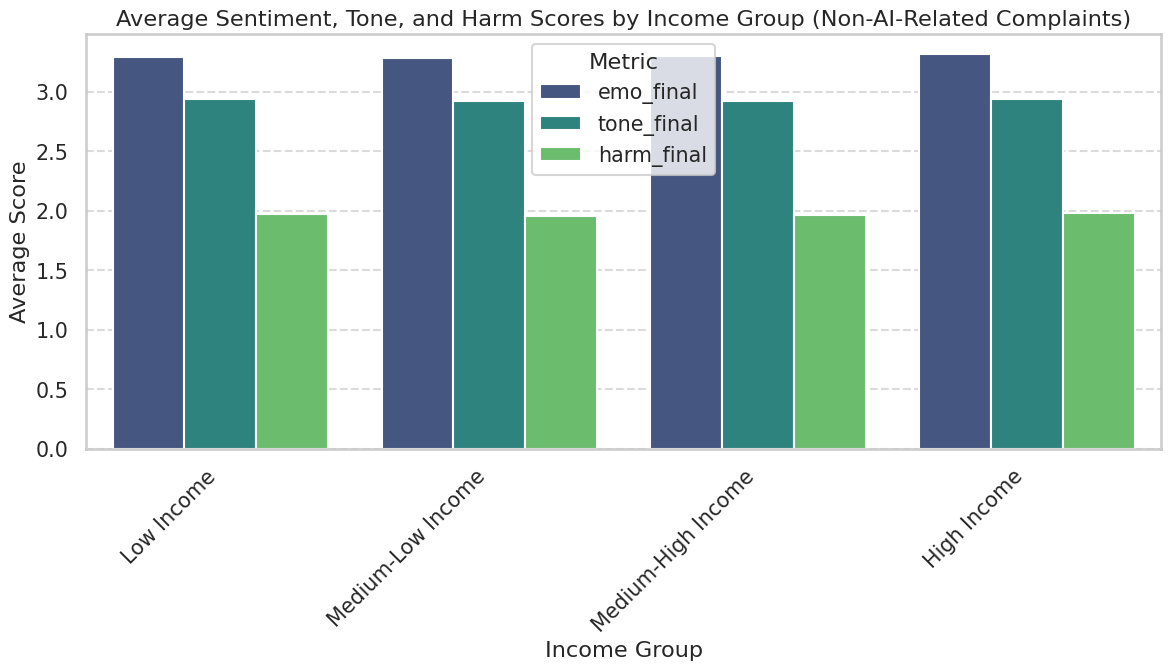

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index to make 'Income_Group' a column for melting
avg_scores_reset_non_ai = average_scores_per_income_group_non_ai.reset_index()

# Melt the DataFrame to long format
avg_scores_melted_non_ai = avg_scores_reset_non_ai.melt(id_vars=['Income_Group'],
                                          var_name='Metric',
                                          value_name='Average Score')

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Income_Group', y='Average Score', hue='Metric', data=avg_scores_melted_non_ai, palette='viridis')

# Add title and labels
plt.title('Average Sentiment, Tone, and Harm Scores by Income Group (Non-AI-Related Complaints)')
plt.xlabel('Income Group')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()